# Imports

In [1]:
import numpy as np
from torch.utils.data import Dataset
import pandas as pd

In [2]:
df_train = pd.read_pickle("/home/ethan2/GrowthCurve/data/train/df_well_train_mad_4.pkl")

In [3]:
df_train

,Well,Plate_ID,Concentration,Compound,Control_Label,Smiles,Timepoint,OD,is_Active,scaffold,maccs_fp,ecfp_fp,rdkit_fp
0,A04,546,0.2,Lefamulin (acetate),0,CC(O)=O.C[C@@H]1C23[C@](C(CC3)=O)([H])C([C@H](...,0.00,0.000000,0,O=C(CSC1CCCCC1)OC1CCCCC23CCCC1C2C(=O)CC3,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, ..."
1,A05,546,0.2,Cefodizime (sodium),0,O=C(C(N12)=C(CSC3=NC(C)=C(CC(O[Na])=O)S3)CS[C@...,0.00,0.000000,0,N=C(C(=O)NC1C(=O)N2C=C(CSc3nccs3)CSC12)c1cscn1,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, ...","[1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, ..."
2,A07,546,0.2,Potassium guaiacolsulfonate (hemihydrate),0,COC1=CC(S(=O)(O[K])=O)=CC=C1O.COC2=C(C=CC=C2O)...,0.00,0.000000,0,c1ccccc1.c1ccccc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,A08,546,0.2,Morinidazole (R enantiomer),0,O[C@@H](CN1C([N+]([O-])=O)=CN=C1C)CN2CCOCC2,0.00,0.000000,0,c1cn(CCCN2CCOCC2)cn1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, ..."
4,A09,546,0.2,Pretomanid,0,FC(F)(F)OC(C=C1)=CC=C1CO[C@@H]2COC3=NC([N+]([O...,0.00,0.000000,0,c1ccc(COC2COc3nccn3C2)cc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
144511,NaN,1886318-Y12-A100,50.0,Z963407962,0,NCC1CCN(C1)C(=O)C=2C=CC=3OCCC3C2,6.24,0.545243,0,O=C(c1ccc2c(c1)CCO2)N1CCCC1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, ..."
144512,NaN,1886318-Y12-A100,50.0,Z963407962,0,NCC1CCN(C1)C(=O)C=2C=CC=3OCCC3C2,12.48,0.971974,0,O=C(c1ccc2c(c1)CCO2)N1CCCC1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, ..."
144513,NaN,1886318-Y12-A100,50.0,Z994483036,0,NCC1CCN(C1)C(=O)C=2C=CC=C(F)C2F,0.00,0.000000,0,O=C(c1ccccc1)N1CCCC1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, ..."
144514,NaN,1886318-Y12-A100,50.0,Z994483036,0,NCC1CCN(C1)C(=O)C=2C=CC=C(F)C2F,6.24,0.549651,0,O=C(c1ccccc1)N1CCCC1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, ..."


In [4]:
df_train.columns

Index(['Well', 'Plate_ID', 'Concentration', 'Compound', 'Control_Label',
       'Smiles', 'Timepoint', 'OD', 'is_Active', 'scaffold', 'maccs_fp',
       'ecfp_fp', 'rdkit_fp'],
      dtype='object')

# DataClass

In [6]:
from __future__ import annotations
import math, re
from dataclasses import dataclass
from typing import Any, Dict, Iterable, Optional, Tuple, List, Sequence
from typing import Literal
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset
from scipy.interpolate import RectBivariateSpline
from torch.utils.data._utils.collate import default_collate


@dataclass(frozen=True)
class CompoundMeta:
    compound: str
    smiles: str
    pivot_od: pd.DataFrame            # index: Timepoint, columns: Concentration → OD
    pivot_cls: pd.DataFrame           # same axes → is_Active
    t_vals: np.ndarray                # sorted unique timepoints (float)
    c_vals: np.ndarray                # sorted unique concentrations (float)
    single_conc: bool                 # True if only one conc present
    t_min: float
    t_max: float
    logc_min: float
    logc_max: float
    fps_by_family: Dict[str, np.ndarray]  # NEW: per-library fingerprint vectors

class PerCompoundDataset(Dataset):
    """
    Returns one item per compound containing k sampled (t,c) with:
      - y_reg: interpolated OD (regression target)
      - y_cls: interpolated classification target (placeholder for now)
      - features_by_family: dict {family: fingerprint tensor}

    If a compound has >1 concentration → local RectBivariateSpline in (time, log(conc)).
    If only one concentration → calls placeholder _interpolate_regression_single_conc().
    Classification interpolation is also a placeholder: _interpolate_classification().

    Output dict keys:
      {
        'compound', 'smiles', 'single_conc',
        't': FloatTensor[k], 'c': FloatTensor[k],
        'y_reg': FloatTensor[k], 'y_cls': FloatTensor[k],   # y_cls presently NaN
        'features_by_family': dict[str, FloatTensor]
      }
    """

    def __init__(
        self,
        df: pd.DataFrame,
        *,
        k: int, 
        log_base: float = 10.0,
        seed: Optional[int] = None,
        # Control which fingerprint families to include; None = include all present
        compounds: Optional[Iterable[str]] = None, #if wanted to only train on these compounds
        fill_missing_fp: Literal["zero", "error"] = "zero",
    ):
        self.df = df.copy()
        self.k = int(k)
        self.rbs_reg = {'kx': 2, 'ky': 2, 's': 0.0}
        self.kx = int(self.rbs_reg.get('kx', 2))
        self.ky = int(self.rbs_reg.get('ky', 2))
        self.log_base = float(log_base)
        if self.log_base <= 0 or self.log_base == 1:
            raise ValueError("log_base must be > 0 and != 1.") 
        
        self.ln_base = np.log(self.log_base)

        self.rng = np.random.default_rng(seed)

        needed = {'Compound', 'Smiles', 'Timepoint', 'Concentration', 'OD', 'is_Active'}

        self.fp_cols_by_family: List[str] = sorted(self._collect_fp_groups(self.df)) #dict of col names for each fp ['ecfp_fp', 'maccs_fp', 'rdkit_fp']

        if compounds is not None:
            keep = set(compounds)
            self.df = self.df[self.df['Compound'].isin(keep)].reset_index(drop=True) 
            
        # Build per-compound metadata
        self._metas: List[CompoundMeta] = []
        for comp, sub in self.df.groupby('Compound', sort=True): #MAY need to change this to group by SMILES, assuming fp map is injective
            
            sub = sub.sort_values(['Timepoint', 'Concentration'])

            piv_od = sub.pivot(index='Timepoint', columns='Concentration', values='OD') \
                        .sort_index(axis=0).sort_index(axis=1)
            piv_cls = sub.pivot(index='Timepoint', columns='Concentration', values='is_Active') \
                        .sort_index(axis=0).sort_index(axis=1)

            t_vals = piv_od.index.values.astype(float)
            c_vals = piv_od.columns.values.astype(float)
            smiles = str(sub['Smiles'].iloc[0])

            # Per-family fingerprint vectors, consistent length/order across compounds
            fps_by_family: Dict[str, np.ndarray] = {}
            
            for col in self.fp_cols_by_family: #extract fp for associated family (maccs, rdkit, ecfp...)
  
                arr = sub[col].iloc[0]              
                vec = np.array(arr, dtype=np.float32)
                fps_by_family[col] = vec


            single_conc = (c_vals.size == 1)
            meta = CompoundMeta(
                compound=comp,
                smiles=smiles,
                pivot_od=piv_od,
                pivot_cls=piv_cls,
                t_vals=t_vals,
                c_vals=c_vals,
                single_conc=single_conc,
                t_min=float(t_vals.min()),
                t_max=float(t_vals.max()),
                logc_min=float(np.log(c_vals.min()) / self.ln_base),
                logc_max=float(np.log(c_vals.max()) / self.ln_base),
                fps_by_family=fps_by_family,
            )
            self._metas.append(meta)

        if not self._metas:
            raise ValueError("No compounds available after filtering.")

    def __len__(self) -> int:
        return len(self._metas)

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        meta = self._metas[idx]

        t_arr = np.empty(self.k, dtype=np.float32)
        c_arr = np.empty(self.k, dtype=np.float32)
        y_reg = np.empty(self.k, dtype=np.float32)
        y_cls = np.empty(self.k, dtype=np.float32)

        for i in range(self.k):
            
            t = self.rng.uniform(float(meta.t_vals.min()), float(meta.t_vals.max()))

            if meta.single_conc:
                
                c = float(meta.c_vals[0]) #should be 50

                y_r, y_c = self. _interpolate_single_conc(meta, t_samp=t, c_samp=c)  # placeholder


            else:
                
                logc_min, logc_max = np.log(float(meta.c_vals.min()))/self.ln_base, np.log(float(meta.c_vals.max()))/self.ln_base
                
                logc_samp = self.rng.uniform(logc_min, logc_max)
     
                c = float(np.exp(logc_samp * self.ln_base))
                
                y_r, y_c, _ = self._interpolate_multiple_conc(
                    od_pivot=meta.pivot_od, t_vals=meta.t_vals, c_vals=meta.c_vals, t_samp=t, c_samp=c, labels_pivot=meta.pivot_cls,k=4
                )

            t_arr[i], c_arr[i], y_reg[i], y_cls[i] = t, c, y_r, y_c

        # Convert per-family features to tensors
        features_by_family = {fam: torch.from_numpy(vec) for fam, vec in meta.fps_by_family.items()}

        return {
            'compound': meta.compound,
            'smiles': meta.smiles,
            'single_conc': meta.single_conc,
            't': torch.from_numpy(t_arr),
            'c': torch.from_numpy(c_arr),
            'y_reg': torch.from_numpy(y_reg),
            'y_cls': torch.from_numpy(y_cls),          
            'features_by_family': features_by_family,  
        }
    
    def _collect_fp_groups(
        self,
        df: pd.DataFrame,
        FP_REGEX=re.compile(r"^(.+?)_fp"),  # e.g., ["rdkit", "maccs"]
    ) -> List[str]:

        groups: List[str] = []
        for col in df.columns:
            m = FP_REGEX.match(col)
            if not m:
                continue
            groups.append(col)
        return groups
    
    def _interpolate_single_conc(
        self,
        meta: CompoundMeta,
        t_samp: float,
        *,
        c_samp: float,
    ) -> tuple[float, int]:
        """
        Estimate both OD (regression) and label (classification) for the
        single-concentration (50 µM) case at a sampled time.

        Returns
        -------
        (od_est, cls_est)
            od_est : float
                Interpolated OD value, clamped to max observed OD after t=0.
            cls_est : int
                Interpolated binary label (0 or 1).
        """

        
        # OD estimation
        if c_samp not in (50, 50.0):
            raise ValueError(f"Single-conc mode expects c==50; got {c_samp!r}")

        times_expected = np.array([0.0, 6.24, 12.48], dtype=float)

        try:
            y_obs = meta.pivot_od.loc[times_expected, 50.0].to_numpy(dtype=float)
        except KeyError as e:
            raise ValueError(
                "Required concentration 50.0 or times [0.0, 6.24, 12.48] not found in pivot_od"
            ) from e

        if np.isnan(y_obs).any():
            raise ValueError("NaN detected in OD values at conc=50 for required times")

        coeffs = np.polyfit(times_expected, y_obs, deg=2)
        od_est = float(np.polyval(coeffs, t_samp))

        # Clamp against later observed max (exclude t=0.0)
        later_mask = times_expected > 1e-6
        cap = float(np.nanmax(y_obs[later_mask]))
        od_est = min(od_est, cap)

        
        # Label estimation
        try:
            cls_series = meta.pivot_cls.loc[:, 50.0]
        except KeyError as e:
            raise ValueError("Classification labels at concentration 50.0 not found in pivot_cls") from e

        times = cls_series.index.values.astype(float)
        labels = cls_series.to_numpy(dtype=int)

        idx_sorted = np.argsort(np.abs(times - t_samp))
        i1, i2 = idx_sorted[:2]
        t1, t2 = times[i1], times[i2]
        l1, l2 = labels[i1], labels[i2]

        if l1 == l2:
            cls_est = int(l1)
        else:
            # Ensure (t1, l1) is the negative and (t2, l2) the positive
            if l1 == 1 and l2 == 0:
                t1, t2 = t2, t1
                l1, l2 = l2, l1

            dist_total = abs(t2 - t1)
            dist_to_pos = abs(t_samp - t2)
            prob_1 = 1.0 - dist_to_pos / dist_total
            cls_est = int(self.rng.uniform() < prob_1)

        return od_est, cls_est

    def _interpolate_multiple_conc(
        self,
        *,
        od_pivot: pd.DataFrame,
        t_vals: np.ndarray,
        c_vals: np.ndarray,
        t_samp: float,
        c_samp: float,   # linear concentration
        labels_pivot: pd.DataFrame | None = None,
        k: int = 4,
    ) -> tuple[float, int, float]:

        kx, ky = self.kx, self.ky
        need_t0, need_c0 = kx + 1, ky + 1

        if t_vals.size < need_t0 or c_vals.size < need_c0:
            raise ValueError(
                f"Not enough unique values for spline: have {t_vals.size} timepoints "
                f"and {c_vals.size} concentrations; need at least {need_t0} and {need_c0}."
            )

        def nearest_k(vals: np.ndarray, target: float, k: int, logspace: bool = False) -> np.ndarray:
            if logspace:
                idx = np.argsort(np.abs(np.log(vals) - np.log(target)))[:k]
            else:
                idx = np.argsort(np.abs(vals - target))[:k]
            return np.sort(vals[idx])

        # Choose nearest neighbors for spline
        times_used = nearest_k(t_vals, t_samp, need_t0, logspace=False)
        concs_used = nearest_k(c_vals, c_samp, need_c0, logspace=True)

        # Build local OD grid
        grid = od_pivot.loc[times_used, concs_used]
        if grid.isna().any().any():
            raise ValueError("Local rectangle has missing cells; cannot fit spline.")

        X = grid.index.values.astype(float)                              # timepoints
        Ylog = np.log(grid.columns.values.astype(float)) / self.ln_base  # log concentrations
        Z = grid.to_numpy()

        # Fit local spline in (time, logC) space
        spline = RectBivariateSpline(X, Ylog, Z, kx=kx, ky=ky, s=0.0)

        # Interpolated OD
        logc_samp = np.log(c_samp) / self.ln_base
        od_hat = float(spline.ev(t_samp, logc_samp))

        # --- Classification (distance-weighted k-NN) ---
        pred_label, p_active = -1, np.nan
        if labels_pivot is not None:
            # Collect all valid datapoints
            coords_time, coords_conc = np.meshgrid(
                labels_pivot.index.values.astype(float),
                labels_pivot.columns.values.astype(float),
                indexing="ij"
            )
            coords_time = coords_time.ravel()
            coords_conc = coords_conc.ravel()
            coords_logc = np.log(coords_conc) / self.ln_base
            coords_od = od_pivot.to_numpy().ravel()
            coords_labels = labels_pivot.to_numpy().ravel()

            mask = ~np.isnan(coords_od) & ~np.isnan(coords_labels)
            coords_time, coords_logc, coords_od, coords_labels = (
                coords_time[mask], coords_logc[mask],
                coords_od[mask], coords_labels[mask].astype(int)
            )

            # Query point (t, logC, interpolated OD)
            query = np.array([t_samp, logc_samp, od_hat])
            coords = np.column_stack([coords_time, coords_logc, coords_od]) # creates 2D array of [[time,conc,OD],[...],...] so every point is an array

            dists = np.linalg.norm(coords - query, axis=1)
            nn_idx = np.argsort(dists)[:k]

            nn_labels = coords_labels[nn_idx]
            nn_dists = dists[nn_idx]

            eps = 1e-8
            weights = 1.0 / (nn_dists + eps) # Gaussain weights could be a good idea here exp(-dist²/σ²
            p_active = float(np.sum(weights * nn_labels) / np.sum(weights))
            pred_label = int(p_active >= 0.5)

        return od_hat, pred_label, p_active


def custom_collate(batch):
        """
        Custom collate function for PerCompoundDataset.

        Args:
            batch (list of dict): Each item is the output of __getitem__.

        Returns:
            dict: Batched output with stacked tensors and lists.
        """
        # Handle fingerprint features separately
        features_by_family = {}
        for fam in batch[0]['features_by_family'].keys():
            features_by_family[fam] = torch.stack(
                [item['features_by_family'][fam] for item in batch]
            )

        # Collate everything else using PyTorch’s default
        collated = {}
        for key in batch[0].keys():
            if key == 'features_by_family':
                continue
            collated[key] = default_collate([item[key] for item in batch])

        # Add fingerprints back
        collated['features_by_family'] = features_by_family
        return collated



In [7]:
from torch.utils.data import DataLoader
ds = PerCompoundDataset(df_train, k=5, seed=42)

In [9]:

loader = DataLoader(ds, batch_size=32, collate_fn=custom_collate)

batch = next(iter(loader))
print(batch['t'].shape)                     # torch.Size([32, 5])
print(batch['features_by_family']['ecfp_fp'].shape)  # torch.Size([32, d1])

torch.Size([32, 5])
torch.Size([32, 2048])


In [10]:
# --- imports you’ll need ---
import numpy as np
import torch
from torch.utils.data import DataLoader

# --- your rbs config (local 3×3, exact interpolation for regression) ---
rbs_kwargs_reg = {"kx": 2, "ky": 2, "s": 0.0}

# --- build the dataset ---
'''
ds = PerCompoundDataset(
    df_train,                 # your big dataframe
    k=8,                      # return 5 sampled (t,c) points per compound
    log_base=10.0,
    seed=123,                 # make sampling reproducible

)
'''

# --- inspect the first sample (one compound) ---
item = ds[0]

print("Compound:", item["compound"])
print("SMILES  :", item["smiles"])
print("Single concentration only?:", item["single_conc"])
print()

print("t (times):", item["t"].numpy())
print("c (concs):", item["c"].numpy())
print("y_reg (OD, interpolated):", item["y_reg"].numpy())
print("y_cls (classification, placeholder):", item["y_cls"].numpy())  # likely NaNs until you implement
print()

# Per-family fingerprint tensors
print("Fingerprint families available:", list(item["features_by_family"].keys()))
for fam, tensor in item["features_by_family"].items():
    arr = tensor.numpy()
    nnz = int((arr != 0).sum())
    print(f"  • {fam}: shape={tuple(arr.shape)}, nnz={nnz}, first 10 bits={arr[:10].astype(int)}")

# --- (optional) use a DataLoader and peek at a small batch ---
loader = DataLoader(ds, batch_size=4, shuffle=True)
batch = next(iter(loader))

print("\nBatch keys:", batch.keys())
print("Batch t shape:", batch["t"].shape)          # [B, k]
print("Batch c shape:", batch["c"].shape)          # [B, k]
print("Batch y_reg shape:", batch["y_reg"].shape)  # [B, k]
print("Batch y_cls shape:", batch["y_cls"].shape)  # [B, k]

# Per-family features come as a dict of tensors stacked across the batch
fam_keys = list(batch["features_by_family"].keys())
print("Batch fingerprint families:", fam_keys)
for fam in fam_keys:
    print(f"  • {fam} batch tensor shape:", batch["features_by_family"][fam].shape)  # [B, n_bits]


Compound: (+)-Camphor
SMILES  : CC1(C)[C@@]2(C)CC[C@@H]1CC2=O
Single concentration only?: False

t (times): [11.436024   4.097948  10.5900345 10.03881    7.898812 ]
c (concs): [2.8459308 3.8456566 7.343368  3.788489  0.9817703]
y_reg (OD, interpolated): [0.9688159  0.5838495  0.95699495 0.94043964 0.8649144 ]
y_cls (classification, placeholder): [0. 0. 0. 0. 0.]

Fingerprint families available: ['ecfp_fp', 'maccs_fp', 'rdkit_fp']
  • ecfp_fp: shape=(2048,), nnz=24, first 10 bits=[0 0 0 0 0 0 0 0 0 0]
  • maccs_fp: shape=(167,), nnz=24, first 10 bits=[0 0 0 0 0 0 0 0 0 0]
  • rdkit_fp: shape=(2048,), nnz=188, first 10 bits=[0 0 0 0 0 0 0 0 0 0]

Batch keys: dict_keys(['compound', 'smiles', 'single_conc', 't', 'c', 'y_reg', 'y_cls', 'features_by_family'])
Batch t shape: torch.Size([4, 5])
Batch c shape: torch.Size([4, 5])
Batch y_reg shape: torch.Size([4, 5])
Batch y_cls shape: torch.Size([4, 5])
Batch fingerprint families: ['ecfp_fp', 'maccs_fp', 'rdkit_fp']
  • ecfp_fp batch tensor sha

In [11]:
len(ds._metas)

cmp=ds._metas[456]
print(cmp.pivot_cls)



Concentration  0.2   1.2   7.9   50.0
Timepoint                            
0.00              0     0     0     0
2.08              0     0     0     0
4.16              0     0     0     0
6.24              0     0     0     0
8.32              0     0     0     0
10.40             0     0     0     1
12.48             0     0     0     0


In [12]:

coords_time, coords_conc = np.meshgrid(
    cmp.pivot_cls.index.values.astype(float),
    cmp.pivot_cls.columns.values.astype(float),
    indexing="ij"
)
coords_time, coords_conc

(array([[ 0.  ,  0.  ,  0.  ,  0.  ],
        [ 2.08,  2.08,  2.08,  2.08],
        [ 4.16,  4.16,  4.16,  4.16],
        [ 6.24,  6.24,  6.24,  6.24],
        [ 8.32,  8.32,  8.32,  8.32],
        [10.4 , 10.4 , 10.4 , 10.4 ],
        [12.48, 12.48, 12.48, 12.48]]),
 array([[ 0.2,  1.2,  7.9, 50. ],
        [ 0.2,  1.2,  7.9, 50. ],
        [ 0.2,  1.2,  7.9, 50. ],
        [ 0.2,  1.2,  7.9, 50. ],
        [ 0.2,  1.2,  7.9, 50. ],
        [ 0.2,  1.2,  7.9, 50. ],
        [ 0.2,  1.2,  7.9, 50. ]]))

In [13]:
coords_time.ravel(), coords_conc.ravel()

(array([ 0.  ,  0.  ,  0.  ,  0.  ,  2.08,  2.08,  2.08,  2.08,  4.16,
         4.16,  4.16,  4.16,  6.24,  6.24,  6.24,  6.24,  8.32,  8.32,
         8.32,  8.32, 10.4 , 10.4 , 10.4 , 10.4 , 12.48, 12.48, 12.48,
        12.48]),
 array([ 0.2,  1.2,  7.9, 50. ,  0.2,  1.2,  7.9, 50. ,  0.2,  1.2,  7.9,
        50. ,  0.2,  1.2,  7.9, 50. ,  0.2,  1.2,  7.9, 50. ,  0.2,  1.2,
         7.9, 50. ,  0.2,  1.2,  7.9, 50. ]))

In [14]:
coords_od = cmp.pivot_od.to_numpy().ravel()
coords_labels = cmp.pivot_cls.to_numpy().ravel()
coords_labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0])

In [15]:
cmp.pivot_od

Concentration,0.2,1.2,7.9,50.0
Timepoint,,,,
0.00,0.000000,0.000000,0.000000,0.000000
2.08,0.268066,0.285601,0.244985,0.220296
4.16,0.549830,0.651573,0.550577,0.451888
6.24,0.718423,0.827879,0.690362,0.655666
8.32,0.827109,0.929350,0.788991,0.738459
10.40,0.927216,0.992340,0.863792,0.823200
12.48,0.994453,1.047222,0.949122,0.918011


In [16]:
np.column_stack([coords_time.ravel(), coords_conc.ravel(), coords_od])

array([[ 0.        ,  0.2       ,  0.        ],
       [ 0.        ,  1.2       ,  0.        ],
       [ 0.        ,  7.9       ,  0.        ],
       [ 0.        , 50.        ,  0.        ],
       [ 2.08      ,  0.2       ,  0.26806599],
       [ 2.08      ,  1.2       ,  0.28560122],
       [ 2.08      ,  7.9       ,  0.24498502],
       [ 2.08      , 50.        ,  0.22029625],
       [ 4.16      ,  0.2       ,  0.54982998],
       [ 4.16      ,  1.2       ,  0.65157295],
       [ 4.16      ,  7.9       ,  0.55057692],
       [ 4.16      , 50.        ,  0.45188765],
       [ 6.24      ,  0.2       ,  0.71842296],
       [ 6.24      ,  1.2       ,  0.82787899],
       [ 6.24      ,  7.9       ,  0.69036204],
       [ 6.24      , 50.        ,  0.65566628],
       [ 8.32      ,  0.2       ,  0.82710946],
       [ 8.32      ,  1.2       ,  0.92935002],
       [ 8.32      ,  7.9       ,  0.78899137],
       [ 8.32      , 50.        ,  0.73845949],
       [10.4       ,  0.2       ,  0.927

# Spline investigation

I need to get a feel for how RectBivariateSpline works. I need to chose a compound and and visualize the interpolation. I should:

-Investigate how many points I should use to do the inteprolation (all or is n sufficient)
-Vary the hyper-parameters of the spline and see how it works.

In [9]:
import pandas as pd
import numpy as np
from scipy.interpolate import RectBivariateSpline

df_train = pd.read_pickle("/home/ethan2/GrowthCurve/data/train/df_well_train_mad_4.pkl")

In [13]:
df_train[(df_train['is_Active'] == 1) & (df_train['Timepoint']==12.48) & (df_train['Concentration']==50)]
#Lefamulin (acetate) seems like a strong antobiotic
#Salinomycin (sodium salt) maybe less so

,Well,Plate_ID,Concentration,Compound,Control_Label,Smiles,Timepoint,OD,is_Active,scaffold,maccs_fp,ecfp_fp,rdkit_fp
52734,A04,546,50.0,Lefamulin (acetate),0,CC(O)=O.C[C@@H]1C23[C@](C(CC3)=O)([H])C([C@H](...,12.48,0.016784,1,O=C(CSC1CCCCC1)OC1CCCCC23CCCC1C2C(=O)CC3,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, ..."
52735,A05,546,50.0,Cefodizime (sodium),0,O=C(C(N12)=C(CSC3=NC(C)=C(CC(O[Na])=O)S3)CS[C@...,12.48,0.000000,1,N=C(C(=O)NC1C(=O)N2C=C(CSc3nccs3)CSC12)c1cscn1,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, ...","[1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, ..."
52741,A12,546,50.0,AFN-1252,0,O=C(N(C)CC1=C(C)C2=CC=CC=C2O1)/C=C/C(C=C3CC4)=...,12.48,0.066888,1,O=C1CCC2=CC(C=CC(=O)NCc3cc4ccccc4o3)=CNC2=N1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, ...","[0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, ..."
52742,A13,546,50.0,Lipofermata,0,O=C1NC2=C(C=C(Br)C=C2)C13SC(C4=CC=CC=C4)=NN3,12.48,0.010547,1,O=C1Nc2ccccc2C12NN=C(c1ccccc1)S2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, ..."
52743,A14,546,50.0,LolCDE-IN-1,0,FC1=CC=C(COC2=CC(C3=NNC=C3C4=CC=NC=C4)=CC=C2)C=C1,12.48,0.000000,1,c1ccc(COc2cccc(-c3n[nH]cc3-c3ccncc3)c2)cc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
107960,NaN,1886318-Y12-A057,50.0,Z3759792316,0,CC1CCC(CC1)C(NC=2N=C(N)N=C(N)N2)C=3C=CC=CC3C,12.48,0.795621,1,c1ccc(C(Nc2ncncn2)C2CCCCC2)cc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, ..."
108284,NaN,1886318-Y12-A058,50.0,Z1349163419,0,OCCN(CC=1C=CC=NC1)C=2C=CC([N+](=O)[O-])=C3C=CC...,12.48,0.805175,1,c1cncc(CNc2cccc3cccnc23)c1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, ..."
119294,NaN,1886318-Y12-A071,50.0,Z1470694932,0,[O-][N+](=O)C=1C=C(Cl)C=NC1SC2=NC=CN2,12.48,0.750972,1,c1ccc(Sc2ncc[nH]2)nc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, ..."
126548,NaN,1886318-Y12-A080,50.0,Z1267882227,0,NCC=1C=CC(=CC1)C2=NC(=CS2)C=3C=CC(F)=C(Cl)C3,12.48,0.780993,1,c1ccc(-c2csc(-c3ccccc3)n2)cc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, ..."


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D)
from scipy.interpolate import RectBivariateSpline
from math import sqrt, log
import plotly.graph_objects as go

from mpl_toolkits.mplot3d import Axes3D

def fit_and_plot_rect_bivariate_spline(
    df: pd.DataFrame,
    compound: str,
    *,
    n_points: int | None = None,
    agg: str = "mean",
    rbs_kwargs: dict | None = None,
    eval_grid_size: int = 100,
    return_objects: bool = True,
):
    """
    Fit RectBivariateSpline to OD over a (Timepoint x Concentration) grid
    for a single compound, and plot the 3D surface.

    Parameters
    ----------
    df : DataFrame
        Must include columns: 'Compound', 'Timepoint', 'Concentration', 'OD'.
    compound : str
        Exact compound name to filter by (e.g., 'Lefamulin (acetate)').
    n_points : int | None
        Approximate number of grid *cells* to use for fitting.
        If None, use all unique Timepoints and Concentrations available.
        Internally this will subsample unique Timepoints and Concentrations
        to get about n_points total cells, preserving min/max coverage.
    agg : {"mean","median"}
        How to aggregate OD if there are multiple wells per (Timepoint, Concentration).
    rbs_kwargs : dict
        Extra kwargs passed to RectBivariateSpline, e.g. {'kx':3,'ky':3,'s':0}.
        Defaults to {'kx': 3, 'ky': 3, 's': 0}.
    eval_grid_size : int
        Resolution of the dense evaluation grid for plotting (eval_grid_size x eval_grid_size).
    return_objects : bool
        If True, return (spline, fig, ax). Otherwise return None.

    Returns
    -------
    (spline, fig, ax) or None
    """
    if rbs_kwargs is None:
        rbs_kwargs = {"kx": 3, "ky": 3, "s": 0}

    if agg not in {"mean", "median"}:
        raise ValueError("agg must be 'mean' or 'median'")

    # Filter to compound
    sub = df.loc[df["Compound"] == compound, ["Timepoint", "Concentration", "OD"]].copy()
    if sub.empty:
        raise ValueError(f"No rows found for Compound == {compound!r}")

    # Aggregate to one OD per (Timepoint, Concentration)
    agg_func = np.mean if agg == "mean" else np.median
    g = (sub
         .groupby(["Timepoint", "Concentration"], as_index=False)
         .agg(OD=("OD", agg_func)))

    # Build pivot grid (rows: Timepoint, cols: Concentration)
    grid = g.pivot(index="Timepoint", columns="Concentration", values="OD").sort_index(axis=0).sort_index(axis=1)

    # Optionally downsample grid to ~n_points cells while keeping range coverage
    def _subsample_axis(vals: np.ndarray, target_count: int) -> np.ndarray:
        """Pick a roughly even subsample (including min & max)."""
        if target_count >= len(vals):
            return vals
        # Evenly spaced indices across the sorted unique values
        idx = np.linspace(0, len(vals) - 1, target_count).round().astype(int)
        return vals[np.unique(idx)]

    if n_points is not None:
        # Decide counts for timepoints and concentrations that multiply to about n_points
        uniq_t = grid.index.to_numpy()
        uniq_c = grid.columns.to_numpy()
        # Start with sqrt split
        nt = max(2, min(len(uniq_t), int(round(sqrt(n_points)))))
        nc = max(2, min(len(uniq_c), int(round(n_points / nt)) if nt > 0 else len(uniq_c)))
        # Ensure at least 2 each for spline orders
        nt = max(2, nt)
        nc = max(2, nc)

        sub_t = _subsample_axis(uniq_t, nt)
        sub_c = _subsample_axis(uniq_c, nc)
        grid = grid.loc[grid.index.intersection(sub_t), grid.columns.intersection(sub_c)]

    # Drop rows/cols with missing cells to satisfy RectBivariateSpline (needs full grid)
    grid = grid.dropna(axis=0, how="any").dropna(axis=1, how="any")

    # After dropping NaNs we still need >= (kx+1) x (ky+1)
    x = grid.index.values.astype(float)  # Timepoint
    y = grid.columns.values.astype(float)  # Concentration
    z = grid.to_numpy()

    if z.shape[0] < (rbs_kwargs.get("kx", 3) + 1) or z.shape[1] < (rbs_kwargs.get("ky", 3) + 1):
        raise ValueError(
            f"Not enough complete grid points after cleaning: got {z.shape}, "
            f"but need at least (kx+1) x (ky+1) = "
            f"{rbs_kwargs.get('kx',3)+1} x {rbs_kwargs.get('ky',3)+1}. "
            "Try reducing spline order, increasing smoothing s, or ensuring a fuller grid."
        )

    # Fit the spline (expects x increasing, y increasing; z shape = (len(x), len(y)))
    spline = RectBivariateSpline(x, y, z, **rbs_kwargs)

    # Evaluate on a dense grid for visualization
    x_dense = np.linspace(x.min(), x.max(), eval_grid_size)
    y_dense = np.linspace(y.min(), y.max(), eval_grid_size)
    Xd, Yd = np.meshgrid(x_dense, y_dense, indexing="ij")  # shape (eval_grid_size, eval_grid_size)

    # RectBivariateSpline.__call__ evaluates on vectors and returns Z with shape (len(x_dense), len(y_dense))
    Zd = spline(x_dense, y_dense)

    # Plot 3D surface
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(Xd, Yd, Zd, linewidth=0, antialiased=True, alpha=0.9)
    ax.set_xlabel("Timepoint")
    ax.set_ylabel("Concentration")
    ax.set_zlabel("OD")
    ax.set_title(f"RectBivariateSpline — {compound}")

    plt.tight_layout()
    plt.show()

    if return_objects:
        return spline, fig, ax


def fit_and_plot_rect_bivariate_spline_logC(
    df: pd.DataFrame,
    compound: str,
    *,
    n_points: int | None = None,
    agg: str = "mean",
    rbs_kwargs: dict | None = None,
    eval_grid_size: int = 100,
    log_base: float = 10.0,
    return_objects: bool = True,
):
    """
    Fit RectBivariateSpline to OD over (Timepoint x log(Concentration)) for a single compound,
    then plot the surface using original Concentration tick labels.

    Parameters
    ----------
    df : DataFrame with ['Compound','Timepoint','Concentration','OD']
    compound : exact compound name to filter by
    n_points : approx number of grid cells (Timepoint x Concentration) to use; None = all
    agg : {'mean','median'} aggregation for replicates
    rbs_kwargs : dict of RectBivariateSpline kwargs (defaults to {'kx':3,'ky':3,'s':0})
    eval_grid_size : resolution for dense eval/plot grid
    log_base : base for the log transform of Concentration (e.g., 10.0 or np.e)
    return_objects : return (spline, fig, ax, x_vals, y_log_vals) if True

    Returns
    -------
    spline, fig, ax, x_unique, y_log_unique  (if return_objects)
    """

    if rbs_kwargs is None:
        rbs_kwargs = {"kx": 3, "ky": 3, "s": 0}
    if agg not in {"mean", "median"}:
        raise ValueError("agg must be 'mean' or 'median'")
    if log_base <= 0 or log_base == 1:
        raise ValueError("log_base must be > 0 and != 1")

    # Filter to compound and sanity-check concentrations
    sub = df.loc[df["Compound"] == compound, ["Timepoint", "Concentration", "OD"]].copy()
    if sub.empty:
        raise ValueError(f"No rows found for Compound == {compound!r}")
    if (sub["Concentration"] <= 0).any():
        raise ValueError("All concentrations must be > 0 for log transform.")

    # Log-transform concentration axis for fitting
    ln_base = log(log_base)  # so log_base(x) = ln(x)/ln(base)
    sub["logC"] = np.log(sub["Concentration"]) / ln_base

    # Aggregate replicates to one OD per (Timepoint, logC)
    agg_func = np.mean if agg == "mean" else np.median
    g = (sub.groupby(["Timepoint", "logC"], as_index=False)
             .agg(OD=("OD", agg_func)))

    # Pivot to a rectangular grid (rows: Timepoint, cols: logC)
    grid = g.pivot(index="Timepoint", columns="logC", values="OD") \
            .sort_index(axis=0).sort_index(axis=1)

    # Optional ~n_points subsampling while keeping coverage
    def _subsample_axis(vals: np.ndarray, target_count: int) -> np.ndarray:
        if target_count >= len(vals):
            return vals
        idx = np.linspace(0, len(vals) - 1, target_count).round().astype(int)
        return vals[np.unique(idx)]

    if n_points is not None:
        uniq_t = grid.index.to_numpy()
        uniq_lc = grid.columns.to_numpy()
        nt = max(2, min(len(uniq_t), int(round(sqrt(n_points)))))
        nc = max(2, min(len(uniq_lc), int(round(n_points / nt)) if nt > 0 else len(uniq_lc)))
        sub_t = _subsample_axis(uniq_t, nt)
        sub_lc = _subsample_axis(uniq_lc, nc)
        grid = grid.loc[grid.index.intersection(sub_t), grid.columns.intersection(sub_lc)]

    # Drop incomplete rows/cols (RectBivariateSpline needs a full rectangle)
    grid = grid.dropna(axis=0, how="any").dropna(axis=1, how="any")

    # Extract axes and values
    x_vals = grid.index.values.astype(float)      # Timepoint
    y_log_vals = grid.columns.values.astype(float)  # log_base(Concentration)
    z_vals = grid.to_numpy()

    # Check minimum knot requirements: need >= (kx+1) along each axis
    kx = rbs_kwargs.get("kx", 3)
    ky = rbs_kwargs.get("ky", 3)
    if z_vals.shape[0] < (kx + 1) or z_vals.shape[1] < (ky + 1):
        raise ValueError(
            f"Not enough grid points after cleaning: got {z_vals.shape}, "
            f"need at least {(kx+1)} along Timepoint and {(ky+1)} along log(Concentration). "
            "Consider lowering kx/ky, increasing s, or using more data."
        )

    # Fit spline in (Timepoint, logC) space
    spline = RectBivariateSpline(x_vals, y_log_vals, z_vals, **rbs_kwargs)

    # Dense evaluation grid (in logC) for smooth plotting
    x_dense = np.linspace(x_vals.min(), x_vals.max(), eval_grid_size)
    y_log_dense = np.linspace(y_log_vals.min(), y_log_vals.max(), eval_grid_size)
    Xd, Yld = np.meshgrid(x_dense, y_log_dense, indexing="ij")
    Zd = spline(x_dense, y_log_dense)

    # Convert logC grid back to original concentration for labeling the Y axis
    Y_conc_dense = np.exp(Yld * ln_base)

    # --- Plot (3D) with original concentration labels on Y axis ---
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    surf = ax.plot_surface(Y_conc_dense,Xd,Zd, linewidth=0, antialiased=True, alpha=0.9)
    ax.set_xlabel("Concentration")
    ax.set_ylabel("Timepoint")
    ax.set_zlabel("OD")
    ax.set_title(f"RectBivariateSpline (log_{int(log_base) if log_base.is_integer() else log_base} Conc) — {compound}")
    plt.tight_layout()
    plt.show()

    if return_objects:
        return spline, fig, ax, x_vals, y_log_vals

def eval_spline_at_original_conc(spline: RectBivariateSpline, timepoint: float, concentration: float, log_base: float = 10.0) -> float:
    """Evaluate a spline (fit in logC space) at original (timepoint, concentration)."""
    if concentration <= 0:
        raise ValueError("Concentration must be > 0.")
    y_log = np.log(concentration) / np.log(log_base)
    # RectBivariateSpline.ev takes scalars (x, y)
    return float(spline.ev(timepoint, y_log))

def sample_and_fit_local_rbs_logC(
    df: pd.DataFrame,
    compound: str,
    *,
    rbs_kwargs: dict | None = None,    # e.g. {"kx":2,"ky":2,"s":0}
    eval_grid_size: int = 100,
    log_base: float = 10.0,
    rng: np.random.Generator | None = None,
    return_objects: bool = True,
):
    """
    Sample a point (t, c) with t ~ Uniform[min_time, max_time] and
    c ~ LogUniform[min_conc, max_conc], pick the nearest (kx+1) timepoints and
    (ky+1) concentrations, fit RectBivariateSpline on that local rectangle in
    (Timepoint, log_base(Concentration)) space, and plot the 3D surface.
    The sampled point is highlighted on the plot.

    Parameters
    ----------
    df : DataFrame with columns ['Compound','Timepoint','Concentration','OD']
    compound : str
        Compound name to filter.
    rbs_kwargs : dict | None
        Passed to RectBivariateSpline. Defaults to {"kx":2,"ky":2,"s":0}.
        The number of points used along each axis will be (kx+1) and (ky+1).
    eval_grid_size : int
        Dense evaluation grid per axis for smooth plotting.
    log_base : float
        Base for log transform of concentration (e.g., 10.0 or np.e).
    rng : np.random.Generator | None
        Optional RNG for reproducibility. If None, uses default.
    return_objects : bool
        If True, returns (spline, fig, ax, sampled_t, sampled_c, x_sel, c_sel).

    Returns
    -------
    tuple or None
    """
    if rbs_kwargs is None:
        rbs_kwargs = {"kx": 2, "ky": 2, "s": 0}
    kx = int(rbs_kwargs.get("kx", 2))
    ky = int(rbs_kwargs.get("ky", 2))
    if log_base <= 0 or log_base == 1:
        raise ValueError("log_base must be > 0 and != 1")
    if rng is None:
        rng = np.random.default_rng()

    # Filter to compound
    cols_needed = ["Compound", "Timepoint", "Concentration", "OD"]
    missing = [c for c in cols_needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")
    sub = df.loc[df["Compound"] == compound, ["Timepoint", "Concentration", "OD"]].copy()
    if sub.empty:
        raise ValueError(f"No rows found for Compound == {compound!r}")
    if (sub["Concentration"] <= 0).any():
        raise ValueError("Concentrations must be > 0 to use a log scale.")
    if sub.duplicated(["Timepoint", "Concentration"]).any():
        raise ValueError("Duplicate (Timepoint, Concentration) pairs detected (replicates).")

    # Unique sorted axes actually present in data
    t_vals = np.sort(sub["Timepoint"].unique().astype(float))
    c_vals = np.sort(sub["Concentration"].unique().astype(float))

    # Sample t uniformly in [min_t, max_t]; sample c log-uniform in [min_c, max_c]
    t_min, t_max = float(t_vals.min()), float(t_vals.max())
    c_min, c_max = float(c_vals.min()), float(c_vals.max())
    t_samp = rng.uniform(t_min, t_max)

    ln_base = np.log(log_base)
    logc_min, logc_max = np.log(c_min)/ln_base, np.log(c_max)/ln_base
    logc_samp = rng.uniform(logc_min, logc_max)
    c_samp = float(np.exp(logc_samp * ln_base))

    # Pick nearest (kx+1) timepoints and (ky+1) concentrations to the sampled point
    def nearest_k(vals: np.ndarray, target: float, k: int) -> np.ndarray:
        idx = np.argsort(np.abs(vals - target))[:k]
        return np.sort(vals[idx])

    need_t = kx + 1
    need_c = ky + 1

    if t_vals.size < need_t or c_vals.size < need_c:
        raise ValueError(
            f"Not enough unique axis values to support kx={kx}, ky={ky}. "
            f"Have {t_vals.size} timepoints (need ≥{need_t}) and {c_vals.size} concentrations (need ≥{need_c})."
        )

    t_sel = nearest_k(t_vals, t_samp, need_t)
    c_sel = nearest_k(c_vals, c_samp, need_c)
    logc_sel = np.log(c_sel) / ln_base

    # Build a 2D grid Z over (t_sel × c_sel). Ensure every cell exists.
    piv = (sub.pivot(index="Timepoint", columns="Concentration", values="OD")
              .sort_index(axis=0).sort_index(axis=1))
    # Slice to our local rectangle
    try:
        grid = piv.loc[t_sel, c_sel]
    except KeyError:
        # If floating comparators cause alignment issues, reindex with tolerance
        # (fallback: use nearest exact matches by value)
        raise

    # Drop any incomplete rows/cols if needed, but keep at least (kx+1) and (ky+1)
    if grid.isna().any().any():
        # Remove any rows/cols with NaN until rectangle is full or too small
        grid = grid.dropna(axis=0, how="any").dropna(axis=1, how="any")
        if grid.shape[0] < need_t or grid.shape[1] < need_c:
            raise ValueError(
                "Could not form a complete rectangle of observed points around the sample. "
                "Check for missing (Timepoint, Concentration) cells."
            )

    x = grid.index.values.astype(float)             # timepoints (selected)
    y = grid.columns.values.astype(float)           # concentrations (selected, linear)
    y_log = np.log(y) / ln_base
    Z = grid.to_numpy()

    # Ensure spline degrees do not exceed (#points - 1)
    kx_eff = min(kx, len(x) - 1)
    ky_eff = min(ky, len(y_log) - 1)
    rbs_kwargs_eff = dict(rbs_kwargs)
    rbs_kwargs_eff["kx"] = kx_eff
    rbs_kwargs_eff["ky"] = ky_eff

    # Fit local spline in (time, logC) space
    spline = RectBivariateSpline(x, y_log, Z, **rbs_kwargs_eff)

    # Dense evaluation grid across the local rectangle (so the sample lies inside)
    x_dense = np.linspace(x.min(), x.max(), eval_grid_size)
    ylog_dense = np.linspace(y_log.min(), y_log.max(), eval_grid_size)
    Xd, Yld = np.meshgrid(x_dense, ylog_dense, indexing="ij")
    Zd = spline(x_dense, ylog_dense)
    Y_conc_dense = np.exp(Yld * ln_base)

    # Evaluate spline at sampled point for reference (optional)
    z_samp = float(spline.ev(t_samp, logc_samp))

    # --- Plot ---
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(Xd, Y_conc_dense, Zd, linewidth=0, antialiased=True, alpha=0.85)
    # Plot the observed 3×3 points used to fit
    TT, CC = np.meshgrid(x, y, indexing="ij")
    ax.scatter(TT.ravel(), CC.ravel(), Z.ravel(), s=40, depthshade=False)
    # Highlight the sampled point
    ax.scatter([t_samp], [c_samp], [z_samp], s=100, marker="X", depthshade=False)
    ax.set_xlabel("Timepoint")
    ax.set_ylabel("Concentration")
    ax.set_zlabel("OD")
    ax.set_title(f"Local RectBivariateSpline (log Conc) — {compound}\n"
                 f"sampled t={t_samp:.3g}, c={c_samp:.3g} (log_base={log_base})")
    plt.tight_layout()
    plt.show()

    if return_objects:
        return spline, fig, ax, t_samp, c_samp, x, y



In [ ]:
import numpy as np
import pandas as pd
from scipy.interpolate import RectBivariateSpline
import plotly.graph_objects as go

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D)
from scipy.interpolate import RectBivariateSpline
from math import sqrt, log
import plotly.graph_objects as go

def sample_fit_plot_interactive_logC(
    df: pd.DataFrame,
    compound: str,
    *,
    rbs_kwargs: dict | None = None,   # e.g., {"kx":2,"ky":2,"s":0.0}
    eval_grid_size: int = 100,
    log_base: float = 10.0,
    rng: np.random.Generator | None = None,
    show_two_views_toggle: bool = True,
    return_objects: bool = True,
):
    if rbs_kwargs is None:
        rbs_kwargs = {"kx": 2, "ky": 2, "s": 4.0}
    kx = int(rbs_kwargs.get("kx", 2))
    ky = int(rbs_kwargs.get("ky", 2))
    if log_base <= 0 or log_base == 1:
        raise ValueError("log_base must be > 0 and != 1")
    if rng is None:
        rng = np.random.default_rng()

    need_cols = ["Compound", "Timepoint", "Concentration", "OD"]
    miss = [c for c in need_cols if c not in df.columns]
    if miss:
        raise ValueError(f"Missing columns: {miss}")
    sub = df.loc[df["Compound"] == compound, ["Timepoint", "Concentration", "OD"]].copy()
    if sub.empty:
        raise ValueError(f"No rows found for Compound == {compound!r}")
    if (sub["Concentration"] <= 0).any():
        raise ValueError("Concentrations must be > 0 for log scale.")
    if sub.duplicated(["Timepoint", "Concentration"]).any():
        raise ValueError("Duplicate (Timepoint, Concentration) pairs found (replicates).")

    t_vals = np.sort(sub["Timepoint"].unique().astype(float))
    c_vals = np.sort(sub["Concentration"].unique().astype(float))
    need_t, need_c = kx + 1, ky + 1
    if t_vals.size < need_t or c_vals.size < need_c:
        raise ValueError(
            f"Insufficient unique values for kx={kx}, ky={ky}: "
            f"{t_vals.size} times (need ≥{need_t}), {c_vals.size} concentrations (need ≥{need_c})."
        )

    # sample t ~ Uniform, c ~ LogUniform
    t_samp = rng.uniform(float(t_vals.min()), float(t_vals.max()))
    ln_base = np.log(log_base)
    logc_min, logc_max = np.log(float(c_vals.min()))/ln_base, np.log(float(c_vals.max()))/ln_base
    logc_samp = rng.uniform(logc_min, logc_max)
    c_samp = float(np.exp(logc_samp * ln_base))  # keep c in linear units

    def nearest_k(vals, target, k, logspace=False):
        if logspace:
            idx = np.argsort(np.abs(np.log(vals) - np.log(target)))[:k]
        else:
            idx = np.argsort(np.abs(vals - target))[:k]
        return np.sort(vals[idx])

    # Use linear neighbors for time, log neighbors for concentration
    times_used = nearest_k(t_vals, t_samp, need_t, logspace=False)
    concs_used = nearest_k(c_vals, c_samp, need_c, logspace=True)

    piv = (sub.pivot(index="Timepoint", columns="Concentration", values="OD")
             .sort_index(axis=0).sort_index(axis=1))
    grid = piv.loc[times_used, concs_used]
    if grid.isna().any().any():
        raise ValueError("Local rectangle has missing cells; cannot fit local spline here.")

    X = grid.index.values.astype(float)                              # times
    Y = grid.columns.values.astype(float)                            # concentrations (linear)
    Ylog = np.log(Y) / ln_base                                       # log concentrations
    Z = grid.to_numpy()

    # Adjust spline order if small grid
    kx_eff = min(kx, len(X) - 1)
    ky_eff = min(ky, len(Y) - 1)
    rbs_eff = dict(rbs_kwargs, kx=kx_eff, ky=ky_eff)

    # Fit spline in (time, logC) space
    spline = RectBivariateSpline(X, Ylog, Z, **rbs_eff)

    # Dense evaluation grid
    x_dense = np.linspace(X.min(), X.max(), eval_grid_size)
    ylog_dense = np.linspace(Ylog.min(), Ylog.max(), eval_grid_size)
    Xd, Yld = np.meshgrid(x_dense, ylog_dense, indexing="ij")
    Zd = spline(x_dense, ylog_dense)
    Y_conc_dense = np.exp(Yld * ln_base)

    # Evaluate OD at the sampled point
    logc_samp_eval = np.log(c_samp) / ln_base
    z_samp = float(spline.ev(t_samp, logc_samp_eval))

    # Meshes for plotting
    TT_obs, CC_obs = np.meshgrid(X, Y, indexing="ij")        # grid used for spline
    all_t, all_c = np.meshgrid(piv.index.values, piv.columns.values, indexing="ij")  # all observed

    fig = go.Figure()

    # Full surface & all observed points
    surf_tc = go.Surface(x=Xd, y=Y_conc_dense, z=Zd, name="Surface (Time×Conc)",
                         showscale=False, opacity=0.9, visible=True)
    obs_all_tc = go.Scatter3d(
        x=all_t.ravel(), y=all_c.ravel(), z=piv.to_numpy().ravel(),
        mode="markers", marker=dict(size=3, color="gray"), name="All observed", visible=True
    )
    obs_used_tc = go.Scatter3d(
        x=TT_obs.ravel(), y=CC_obs.ravel(), z=Z.ravel(),
        mode="markers", marker=dict(size=7, color="red", symbol="diamond"),
        name="Used for local fit", visible=True
    )
    samp_tc = go.Scatter3d(
        x=[t_samp], y=[c_samp], z=[z_samp],
        mode="markers", marker=dict(size=10, symbol="x", color="blue"),
        name=f"Sampled (OD≈{z_samp:.4g})",
        hovertemplate="t=%{x:.3g}<br>c=%{y:.3g}<br>OD=%{z:.4g}<extra></extra>",
        visible=True
    )

    # Alternative Conc×Time view
    surf_ct = go.Surface(x=Y_conc_dense, y=Xd, z=Zd, name="Surface (Conc×Time)",
                         showscale=False, opacity=0.9, visible=False)
    obs_all_ct = go.Scatter3d(
        x=all_c.ravel(), y=all_t.ravel(), z=piv.to_numpy().ravel(),
        mode="markers", marker=dict(size=3, color="gray"), name="All observed (swapped)", visible=False
    )
    obs_used_ct = go.Scatter3d(
        x=CC_obs.ravel(), y=TT_obs.ravel(), z=Z.ravel(),
        mode="markers", marker=dict(size=7, color="red", symbol="diamond"),
        name="Used for local fit (swapped)", visible=False
    )
    samp_ct = go.Scatter3d(
        x=[c_samp], y=[t_samp], z=[z_samp],
        mode="markers", marker=dict(size=10, symbol="x", color="blue"),
        name=f"Sampled (OD≈{z_samp:.4g}) [swapped]",
        hovertemplate="c=%{x:.3g}<br>t=%{y:.3g}<br>OD=%{z:.4g}<extra></extra>",
        visible=False
    )

    fig.add_traces([surf_tc, obs_all_tc, obs_used_tc, samp_tc,
                    surf_ct, obs_all_ct, obs_used_ct, samp_ct])

    fig.update_layout(
        title=f"{compound} — Local RectBivariateSpline (log Conc) — "
              f"sampled t={t_samp:.3g}, c={c_samp:.3g}, OD≈{z_samp:.4g}",
        scene=dict(
            xaxis_title="Timepoint",
            yaxis_title="Concentration",
            zaxis_title="OD",
            aspectmode="cube",
        ),
        margin=dict(l=0, r=0, b=0, t=60),
        annotations=[dict(text=f"OD@sample ≈ {z_samp:.4g}", x=0.01, y=1.08,
                          xref="paper", yref="paper", showarrow=False)]
    )

    if show_two_views_toggle:
        vis_tc = [True, True, True, True, False, False, False, False]
        vis_ct = [False, False, False, False, True, True, True, True]
        fig.update_layout(
            updatemenus=[dict(
                type="buttons", direction="right", x=0.5, y=1.12, xanchor="center",
                buttons=[
                    dict(label="Time × Conc", method="update",
                         args=[{"visible": vis_tc},
                               {"scene": dict(xaxis_title="Timepoint",
                                              yaxis_title="Concentration",
                                              zaxis_title="OD")}]),
                    dict(label="Conc × Time", method="update",
                         args=[{"visible": vis_ct},
                               {"scene": dict(xaxis_title="Concentration",
                                              yaxis_title="Timepoint",
                                              zaxis_title="OD")}]),
                ],
            )]
        )

    if return_objects:
        return {
            "spline": spline,
            "fig": fig,
            "t_samp": t_samp, "c_samp": c_samp, "z_samp": z_samp,
            "times_used": X, "concs_used": Y
        }
    

import numpy as np
import pandas as pd
import plotly.graph_objects as go


In [31]:
import numpy as np
import pandas as pd
from scipy.interpolate import RectBivariateSpline
import plotly.graph_objects as go

def sample_cls_interpolation_plot(
    df: pd.DataFrame,
    compound: str,
    *,
    k: int = 5,
    log_base: float = 10.0,
    spline_deg: int = 2,
    eval_grid_size: int = 100,
    rng: np.random.Generator | None = None,
    return_objects: bool = True,
):
    """
    Visualize OD interpolation + classification labels for a sampled point.

    - Z axis = OD, X = timepoint, Y = concentration.
    - Fit RectBivariateSpline using (spline_deg+1)^2 nearest grid points.
    - Predict classification label with distance-weighted k-NN in
      (time, log(conc), OD) space:
          d = sqrt((t - t_samp)^2 + (logC - logC_samp)^2 + (OD - OD_samp)^2)
    - Weighted probability:
          p_active = sum(w_i * y_i) / sum(w_i),  w_i = 1 / (d_i + eps)
    - Observed points: dots (blue=0, red=1).
    - k-NN neighbors: X markers (blue=0, red=1).
    - Sampled point: large black X with yellow outline.
    """
    if rng is None:
        rng = np.random.default_rng()

    need_cols = ["Compound", "Timepoint", "Concentration", "OD", "is_Active"]
    miss = [c for c in need_cols if c not in df.columns]
    if miss:
        raise ValueError(f"Missing columns: {miss}")

    sub = df.loc[df["Compound"] == compound,
                 ["Timepoint", "Concentration", "OD", "is_Active"]].copy()
    if sub.empty:
        raise ValueError(f"No rows found for Compound == {compound!r}")

    t_vals = np.sort(sub["Timepoint"].unique().astype(float))
    c_vals = np.sort(sub["Concentration"].unique().astype(float))

    # Sample query point
    t_samp = rng.uniform(float(t_vals.min()), float(t_vals.max()))
    ln_base = np.log(log_base)
    logc_min, logc_max = np.log(float(c_vals.min()))/ln_base, np.log(float(c_vals.max()))/ln_base
    logc_samp = rng.uniform(logc_min, logc_max)
    c_samp = float(np.exp(logc_samp * ln_base))

    # --- Spline neighbors (rectangular grid) ---
    def nearest_k(vals, target, k, logspace=False):
        if logspace:
            idx = np.argsort(np.abs(np.log(vals) - np.log(target)))[:k]
        else:
            idx = np.argsort(np.abs(vals - target))[:k]
        return np.sort(vals[idx])

    need_t = spline_deg + 1
    need_c = spline_deg + 1
    times_used = nearest_k(t_vals, t_samp, need_t, logspace=False)
    concs_used = nearest_k(c_vals, c_samp, need_c, logspace=True)

    piv_od = sub.pivot(index="Timepoint", columns="Concentration", values="OD")
    grid_od = piv_od.loc[times_used, concs_used]

    if grid_od.isna().any().any():
        raise ValueError("Local rectangle has missing cells; cannot fit local spline.")

    X = grid_od.index.values.astype(float)
    Y = grid_od.columns.values.astype(float)
    Z = grid_od.to_numpy()

    spline = RectBivariateSpline(
        X, np.log(Y)/ln_base, Z,
        kx=spline_deg, ky=spline_deg, s=0.0
    )

    # Evaluate spline surface
    x_dense = np.linspace(X.min(), X.max(), eval_grid_size)
    ylog_dense = np.linspace(np.log(Y.min())/ln_base, np.log(Y.max())/ln_base, eval_grid_size)
    Xd, Yld = np.meshgrid(x_dense, ylog_dense, indexing="ij")
    Zd = spline(x_dense, ylog_dense)
    Y_conc_dense = np.exp(Yld * ln_base)

    # Interpolated OD at sampled point
    z_samp = float(spline.ev(t_samp, np.log(c_samp)/ln_base))

    # --- Classification neighbors (k-NN in 3D: time, logC, OD) ---
    times_all = sub["Timepoint"].astype(float).to_numpy()
    concs_all = sub["Concentration"].astype(float).to_numpy()
    ods_all = sub["OD"].to_numpy()
    labels_all = sub["is_Active"].astype(int).to_numpy()

    log_concs_all = np.log(concs_all) / ln_base
    log_c_samp = np.log(c_samp) / ln_base

    coords = np.column_stack([times_all, log_concs_all, ods_all])
    query = np.array([t_samp, log_c_samp, z_samp])

    dists = np.linalg.norm(coords - query, axis=1)
    nn_idx_cls = np.argsort(dists)[:k]

    nn_labels = labels_all[nn_idx_cls]
    nn_dists = dists[nn_idx_cls]

    eps = 1e-8
    weights = 1.0 / (nn_dists + eps)
    p_active = float(np.sum(weights * nn_labels) / np.sum(weights))

    pred_label = int(p_active >= 0.5)

    # --- Visualization ---
    fig = go.Figure()

    # Interpolated OD surface
    surf_tc = go.Surface(
        x=Xd, y=Y_conc_dense, z=Zd,
        colorscale="Viridis", opacity=0.6, showscale=False,
        name="Interpolated OD surface"
    )

    # All observed points (dots)
    obs = go.Scatter3d(
        x=times_all, y=concs_all, z=ods_all,
        mode="markers",
        marker=dict(size=6,
                    color=labels_all,
                    colorscale=[[0, "blue"], [1, "red"]],
                    symbol="circle"),
        name="Observed points"
    )

    # k-NN neighbors (X markers)
    obs_cls = go.Scatter3d(
        x=times_all[nn_idx_cls], y=concs_all[nn_idx_cls], z=ods_all[nn_idx_cls],
        mode="markers",
        marker=dict(size=5,
                    color=nn_labels,
                    colorscale=[[0, "blue"], [1, "red"]],
                    symbol="x"),
        name=f"k-NN neighbors (k={k})"
    )

    # Sampled query point (large black X with outline)
    samp = go.Scatter3d(
        x=[t_samp], y=[c_samp], z=[z_samp],
        mode="markers",
        marker=dict(size=5, color="black", symbol="x",
                    line=dict(width=2, color="yellow")),
        name=f"Sample (pred={pred_label}, p={p_active:.2f})",
        hovertemplate="t=%{x:.3g}<br>c=%{y:.3g}<br>OD≈%{z:.3g}"
                      f"<br>p_active={p_active:.3f}<br>pred={pred_label}<extra></extra>",
    )

    fig.add_traces([surf_tc, obs, obs_cls, samp])

    fig.update_layout(
        title=f"{compound} — OD interpolation + classification "
              f"(pred={pred_label}, p_active={p_active:.2f}, k={k})",
        scene=dict(
            xaxis_title="Timepoint",
            yaxis_title="Concentration",
            zaxis_title="OD",
            aspectmode="cube",
        ),
        margin=dict(l=0, r=0, b=0, t=60),
    )

    if return_objects:
        return {
            "spline": spline,
            "fig": fig,
            "t_samp": t_samp, "c_samp": c_samp, "z_samp": z_samp,
            "p_active": p_active,
            "pred_label": pred_label,
            "nn_idx_cls": nn_idx_cls,
        }


## Active Compounds

UM0106969:01

In [21]:
out = sample_cls_interpolation_plot(df_train, "Zoliflodacin",k=4, spline_deg=2, eval_grid_size=100, log_base=10.0)
print("OD at sampled point (interpolated):")
out["fig"].show()



OD at sampled point (interpolated):


In [50]:
out = sample_cls_interpolation_plot(df_train, "Nosiheptide",k=4, spline_deg=2, eval_grid_size=100, log_base=10.0)
print("OD at sampled point (interpolated):")
out["fig"].show()

#Lefamulin (acetate)

OD at sampled point (interpolated):


# Inactive compounds

In [43]:
out = sample_cls_interpolation_plot(df_train, "Pretomanid",k=4, spline_deg=2, eval_grid_size=100, log_base=10.0)
print("OD at sampled point (interpolated):")
out["fig"].show()




OD at sampled point (interpolated):


# Interpolation 1 conc

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_single_conc_quadratic(df: pd.DataFrame, compound: str,
                               conc_target: float = 50.0,
                               times_expected=(0.0, 6.24, 12.48),
                               tol: float = 1e-6, num_points: int = 200,
                               clamp_to_max_endpoints: bool = True):
    """
    Fit y(t) = a t^2 + b t + c at conc==conc_target using exactly three expected timepoints,
    then plot the quadratic and the observed points. If clamp_to_max_endpoints is True,
    the plotted curve is clamped so its maximum never exceeds max(OD at the later two endpoints).
    Assumes OD at time ~0 is (effectively) 0.

    Returns
    -------
    coeffs : np.ndarray shape (3,)  # [a, b, c]
    fig, ax : matplotlib figure and axis
    """
    # Filter & pivot
    sub = df.loc[df["Compound"] == compound, ["Timepoint", "Concentration", "OD"]].copy()
    if sub.empty:
        raise ValueError(f"No rows for compound {compound!r}.")
    piv = (sub.pivot(index="Timepoint", columns="Concentration", values="OD")
             .sort_index(axis=0).sort_index(axis=1))

    # Find the exact/nearest column to conc_target
    cols = piv.columns.to_numpy(dtype=float)
    j = int(np.argmin(np.abs(cols - conc_target)))
    if abs(cols[j] - conc_target) > tol:
        raise ValueError(f"Expected concentration {conc_target}, got nearest {cols[j]}.")
    conc_col = cols[j]

    # Collect OD at the three required timepoints (with tolerance)
    idx_vals = piv.index.to_numpy(dtype=float)
    t_used, y_used = [], []
    for t_exp in times_expected:
        i = int(np.argmin(np.abs(idx_vals - t_exp)))
        if abs(idx_vals[i] - t_exp) > tol:
            raise ValueError(f"Missing required timepoint {t_exp} (nearest is {idx_vals[i]}).")
        t_used.append(idx_vals[i])
        y_used.append(piv.loc[idx_vals[i], conc_col])

    t_used = np.asarray(t_used, dtype=float)
    y_used = np.asarray(y_used, dtype=float)
    if np.isnan(y_used).any():
        raise ValueError("NaN encountered in required OD values.")

    # Fit quadratic y = a t^2 + b t + c (exact interpolation for 3 points)
    coeffs = np.polyfit(t_used, y_used, deg=2)

    # Evaluate on a dense grid across the observed span
    t_min, t_max = float(min(t_used)), float(max(t_used))
    t_dense = np.linspace(t_min, t_max, num_points)
    y_dense = np.polyval(coeffs, t_dense)

    # ----- SAFEGUARD: clamp the curve to max OD among the two later endpoints -----
    if clamp_to_max_endpoints:
        # Identify which of the provided expected times are the "later endpoints"
        # i.e., exclude the near-zero timepoint using tolerance
        later_mask = np.abs(np.asarray(times_expected, dtype=float)) > tol
        if later_mask.sum() != 2:
            # Fallback: use the two largest times in t_used
            order = np.argsort(t_used)
            later_mask = np.zeros_like(t_used, dtype=bool)
            later_mask[order[-2:]] = True

        cap = float(np.nanmax(y_used[later_mask]))
        y_dense = np.minimum(y_dense, cap)

    # Plot
    fig, ax = plt.subplots(figsize=(6.0, 4.0))
    ax.plot(t_dense, y_dense, label="Quadratic fit (clamped)" if clamp_to_max_endpoints else "Quadratic fit", linewidth=2)
    ax.scatter(t_used, y_used, s=60, zorder=3, label=f"Observed @ {conc_target:g}")
    ax.set_xlabel("Timepoint")
    ax.set_ylabel("OD")
    a, b, c = coeffs
    title = f"{compound} (conc={conc_target:g}): y = {a:.3g} t² + {b:.3g} t + {c:.3g}"
    if clamp_to_max_endpoints:
        title += "  [clamped to max(endpoints)]"
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return coeffs, fig, ax



def plot_single_conc_quadratic_old(df: pd.DataFrame, compound: str,
                               conc_target: float = 50.0,
                               times_expected=(0.0, 6.24, 12.48),
                               tol: float = 1e-6, num_points: int = 200):
    """
    Fit y(t) = a t^2 + b t + c at conc==50 using exactly the three expected timepoints,
    then plot the quadratic and the observed points.

    Parameters
    ----------
    df : DataFrame with columns ['Compound','Timepoint','Concentration','OD']
    compound : str
    conc_target : float
        Expected single concentration (defaults to 50.0).
    times_expected : tuple
        The three timepoints to use for the quadratic fit.
    tol : float
        Tolerance for matching float labels in the pivot.
    num_points : int
        Number of t-values for the smooth curve.

    Returns
    -------
    coeffs : np.ndarray shape (3,)  # [a, b, c]
    fig, ax : matplotlib figure and axis
    """
    # Filter & pivot
    sub = df.loc[df["Compound"] == compound, ["Timepoint", "Concentration", "OD"]].copy()
    if sub.empty:
        raise ValueError(f"No rows for compound {compound!r}.")
    piv = (sub.pivot(index="Timepoint", columns="Concentration", values="OD")
             .sort_index(axis=0).sort_index(axis=1))

    # Find the exact/nearest column to conc_target
    cols = piv.columns.to_numpy(dtype=float)
    j = int(np.argmin(np.abs(cols - conc_target)))
    if abs(cols[j] - conc_target) > tol:
        raise ValueError(f"Expected concentration {conc_target}, got nearest {cols[j]}.")
    conc_col = cols[j]

    # Collect OD at the three required timepoints (with tolerance)
    idx_vals = piv.index.to_numpy(dtype=float)
    t_used, y_used = [], []
    for t_exp in times_expected:
        i = int(np.argmin(np.abs(idx_vals - t_exp)))
        if abs(idx_vals[i] - t_exp) > tol:
            raise ValueError(f"Missing required timepoint {t_exp} (nearest is {idx_vals[i]}).")
        t_used.append(idx_vals[i])
        y_used.append(piv.loc[idx_vals[i], conc_col])

    t_used = np.asarray(t_used, dtype=float)
    y_used = np.asarray(y_used, dtype=float)
    if np.isnan(y_used).any():
        raise ValueError("NaN encountered in required OD values.")

    # Fit quadratic y = a t^2 + b t + c
    coeffs = np.polyfit(t_used, y_used, deg=2)

    # Evaluate on a dense grid across the observed span
    t_min, t_max = float(min(t_used)), float(max(t_used))
    t_dense = np.linspace(t_min, t_max, num_points)
    y_dense = np.polyval(coeffs, t_dense)

    # Plot
    fig, ax = plt.subplots(figsize=(6.0, 4.0))
    ax.plot(t_dense, y_dense, label="Quadratic fit", linewidth=2)
    ax.scatter(t_used, y_used, s=60, zorder=3, label="Observed @ 50")
    ax.set_xlabel("Timepoint")
    ax.set_ylabel("OD")
    a, b, c = coeffs
    ax.set_title(f"{compound} (conc=50): y = {a:.3g} t² + {b:.3g} t + {c:.3g}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return coeffs, fig, ax


In [12]:
# Group by compound and collect all unique concentrations per compound
concs_by_comp = df_train.groupby("Compound")["Concentration"].unique()

# Identify compounds that have exactly one unique concentration, and it's 50
only_50_compounds = concs_by_comp[concs_by_comp.apply(lambda x: len(x) == 1 and x[0] == 50)].index

# Filter the original dataframe to those compounds
df_only_50 = df_train[df_train["Compound"].isin(only_50_compounds)]

df_only_50[df_only_50['is_Active'] == 1]['Compound'].unique()


array(['Z1203873223', 'Z647396922', 'Z1646492194', 'Z1693527467',
       'Z1167728859', 'Z383079852', 'Z1376472169', 'Z226457910',
       'Z510189700', 'Z1439137756', 'Z1590661456', 'Z225101880',
       'Z2233914403', 'Z383152172', 'Z2088388996', 'Z2313243976',
       'Z396500958', 'Z1228838652', 'Z3759792316', 'Z1349163419',
       'Z1542314476', 'Z1470694932', 'Z1267882227', 'Z4215637372'],
      dtype=object)

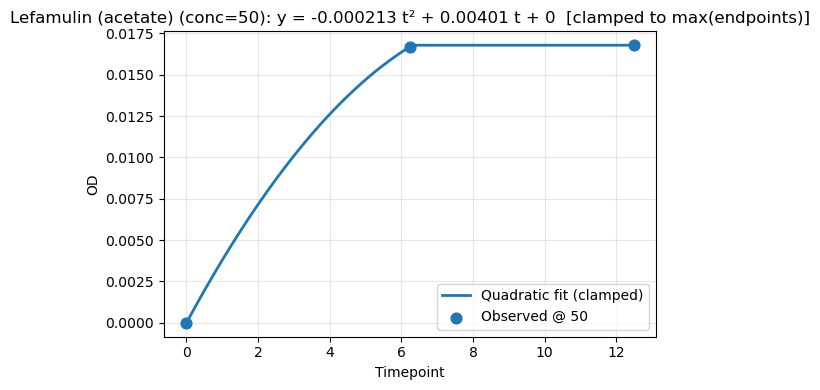

Quadratic coefficients [a, b, c]: [-0.00021334  0.00400741  0.        ]


In [15]:
coeffs, fig, ax = plot_single_conc_quadratic(df_train,"Lefamulin (acetate)")
print("Quadratic coefficients [a, b, c]:", coeffs)


## Actives

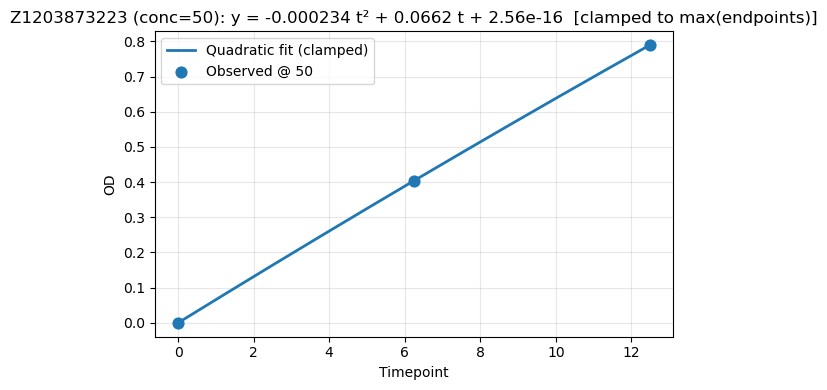

Quadratic coefficients [a, b, c]: [-2.34446874e-04  6.61502911e-02  2.56395025e-16]


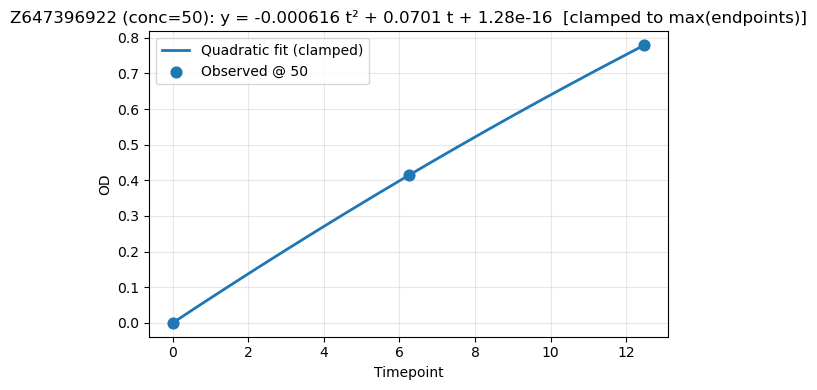

Quadratic coefficients [a, b, c]: [-6.16438220e-04  7.01282192e-02  1.28197512e-16]


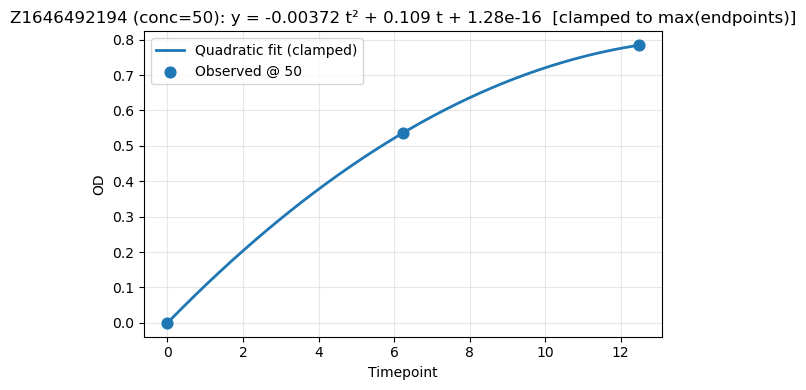

Quadratic coefficients [a, b, c]: [-3.71672202e-03  1.09217844e-01  1.28197512e-16]


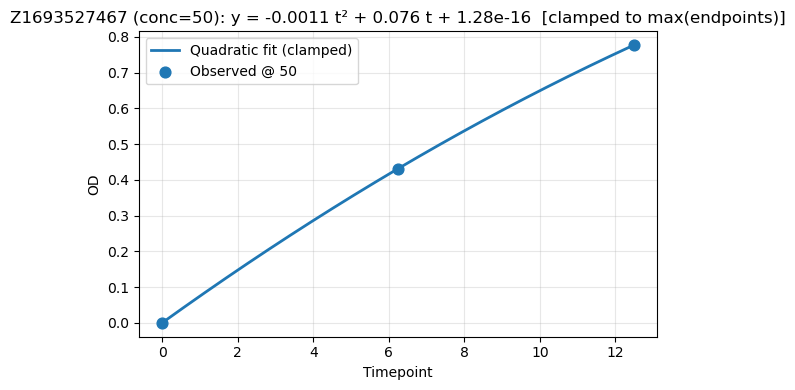

Quadratic coefficients [a, b, c]: [-1.09780451e-03  7.59553526e-02  1.28197512e-16]


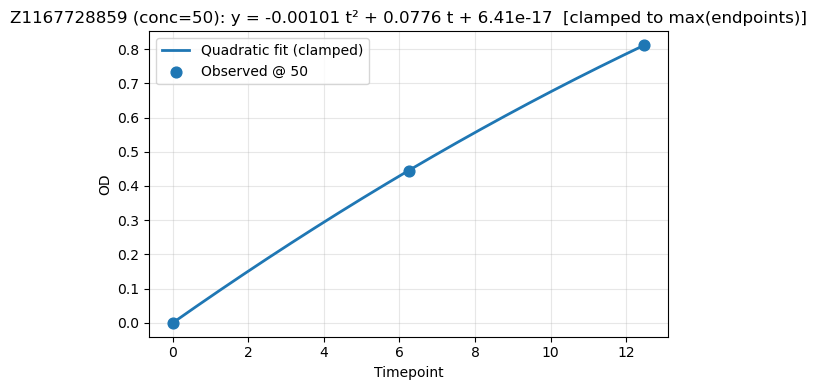

Quadratic coefficients [a, b, c]: [-1.00688641e-03  7.75892355e-02  6.40987562e-17]


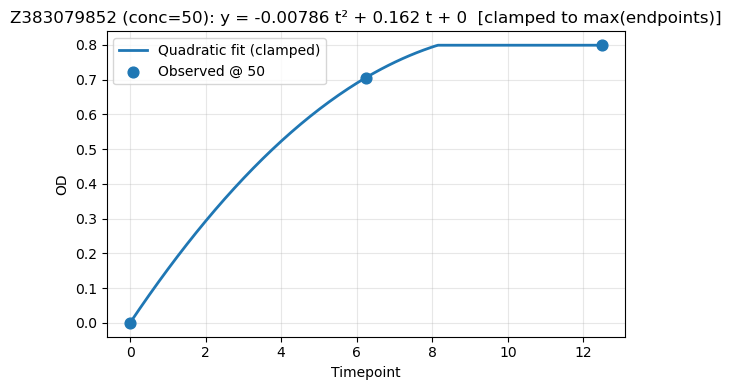

Quadratic coefficients [a, b, c]: [-0.00785938  0.16210063  0.        ]


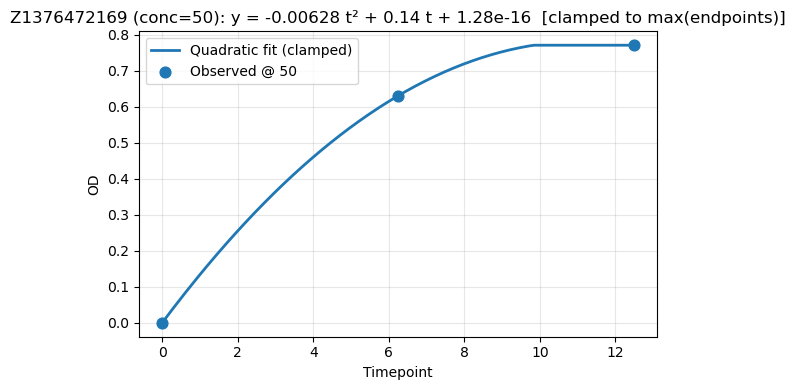

Quadratic coefficients [a, b, c]: [-6.28171225e-03  1.40154557e-01  1.28197512e-16]


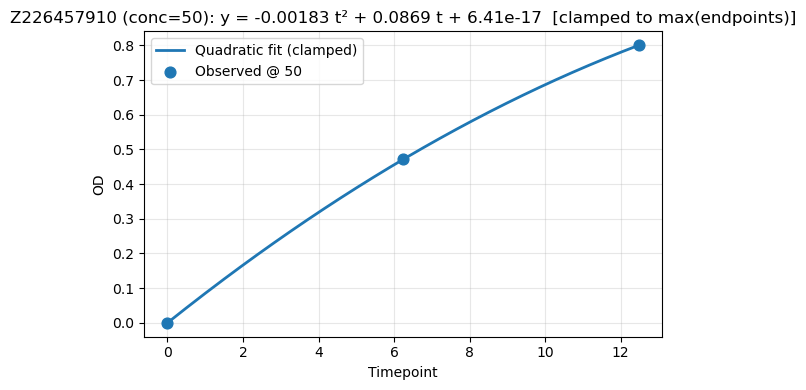

Quadratic coefficients [a, b, c]: [-1.82564706e-03  8.69128627e-02  6.40987562e-17]


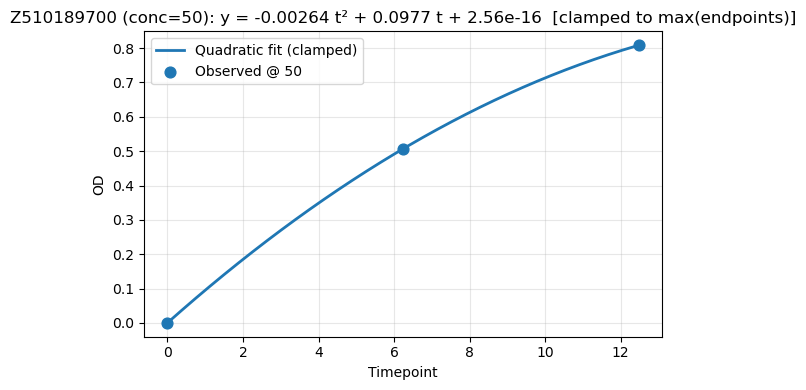

Quadratic coefficients [a, b, c]: [-2.63836082e-03  9.77171887e-02  2.56395025e-16]


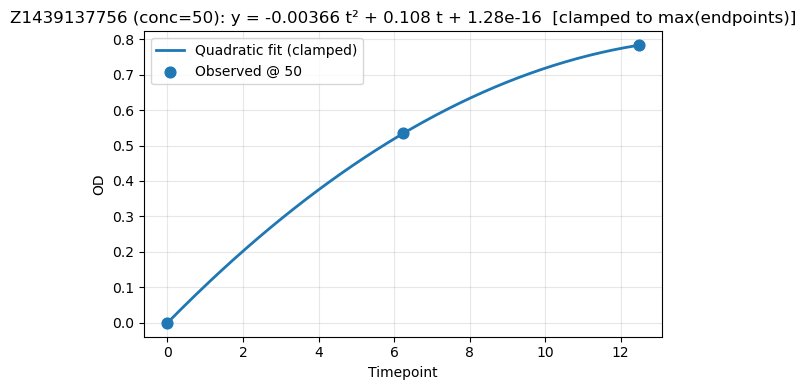

Quadratic coefficients [a, b, c]: [-3.66317638e-03  1.08445113e-01  1.28197512e-16]


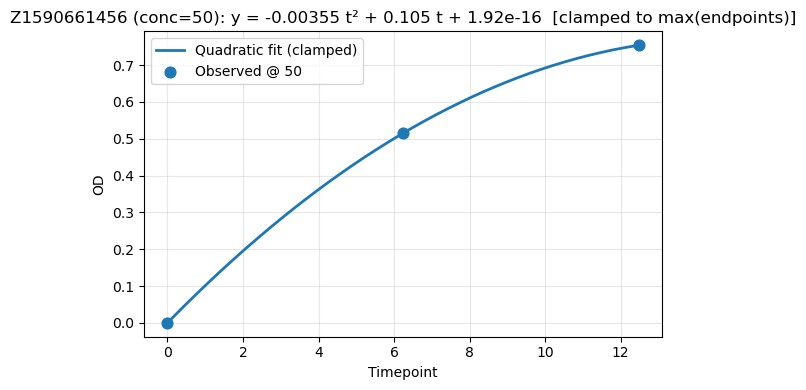

Quadratic coefficients [a, b, c]: [-3.55139409e-03  1.04734159e-01  1.92296269e-16]


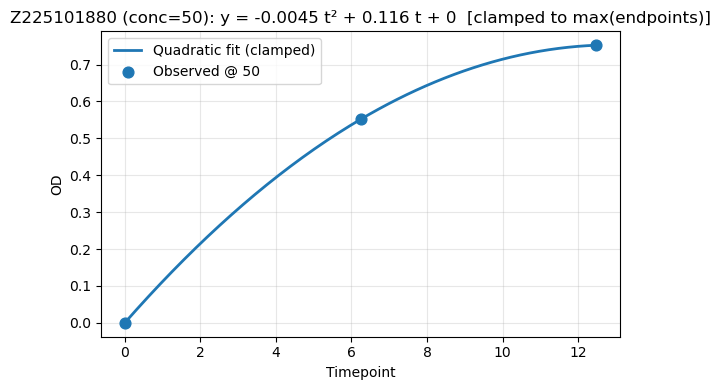

Quadratic coefficients [a, b, c]: [-0.00449914  0.11644768  0.        ]


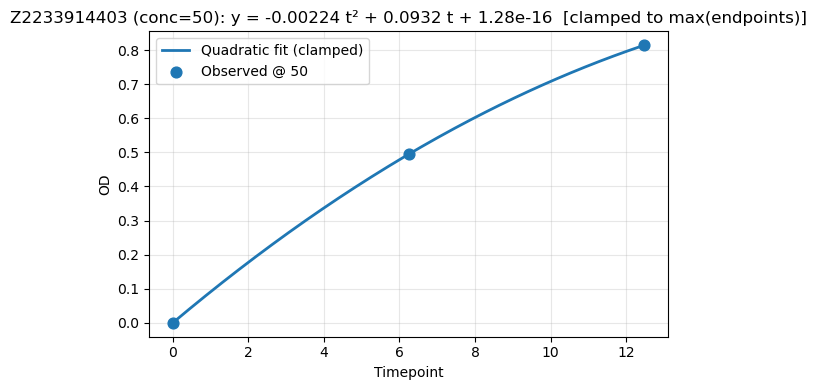

Quadratic coefficients [a, b, c]: [-2.23739214e-03  9.31753010e-02  1.28197512e-16]


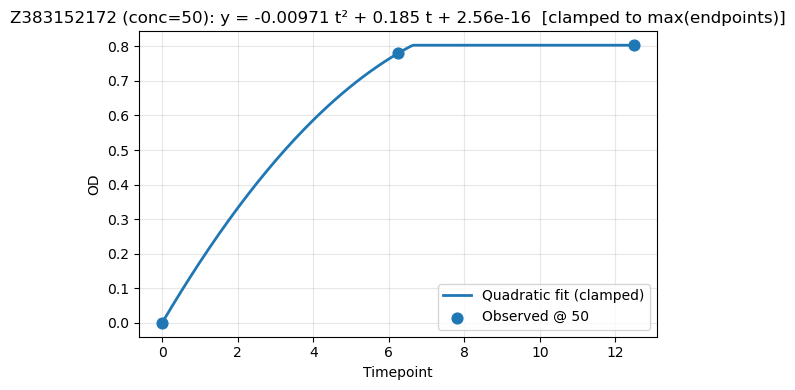

Quadratic coefficients [a, b, c]: [-9.70573638e-03  1.85497067e-01  2.56395025e-16]


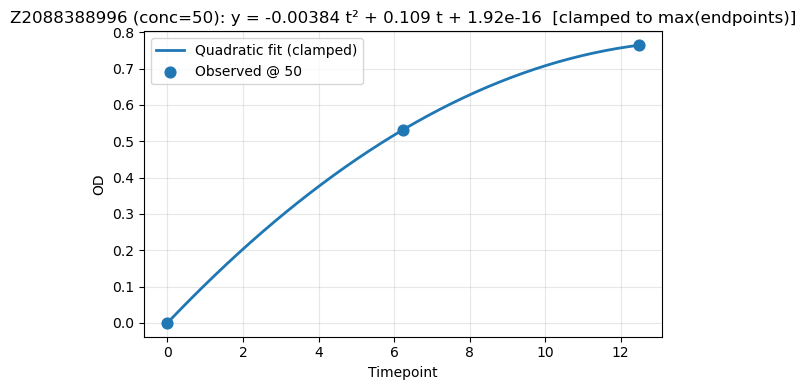

Quadratic coefficients [a, b, c]: [-3.84358881e-03  1.09207472e-01  1.92296269e-16]


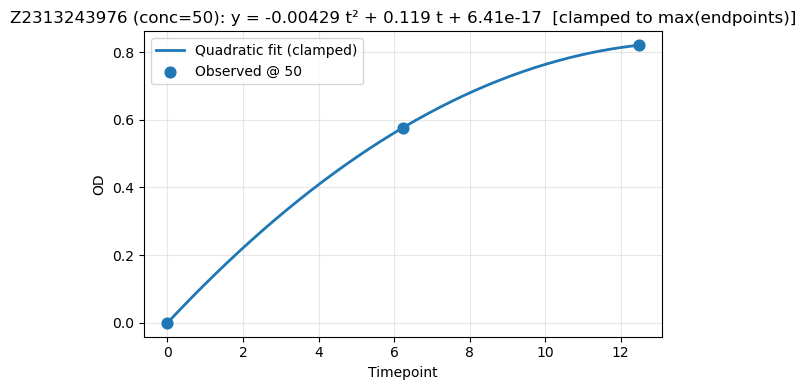

Quadratic coefficients [a, b, c]: [-4.28758706e-03  1.19234942e-01  6.40987562e-17]


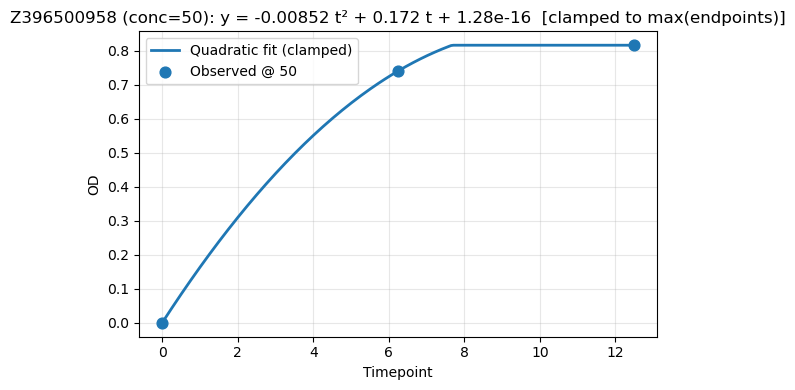

Quadratic coefficients [a, b, c]: [-8.51814575e-03  1.71658884e-01  1.28197512e-16]


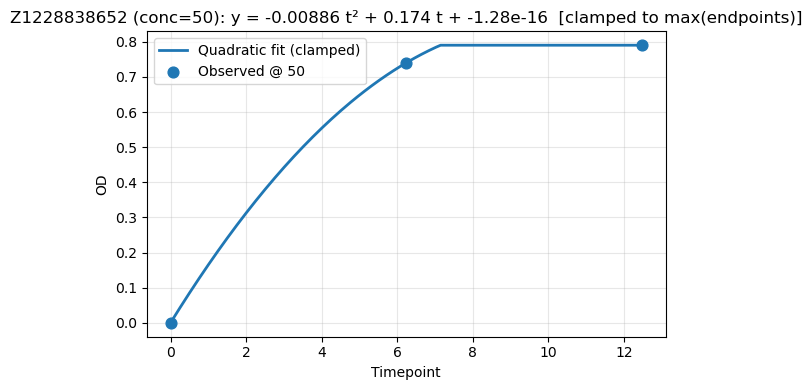

Quadratic coefficients [a, b, c]: [-8.86346063e-03  1.73945006e-01 -1.28197512e-16]


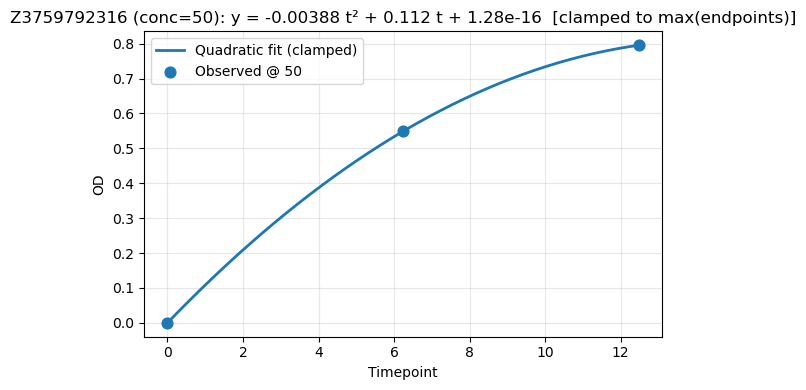

Quadratic coefficients [a, b, c]: [-3.88484674e-03  1.12234565e-01  1.28197512e-16]


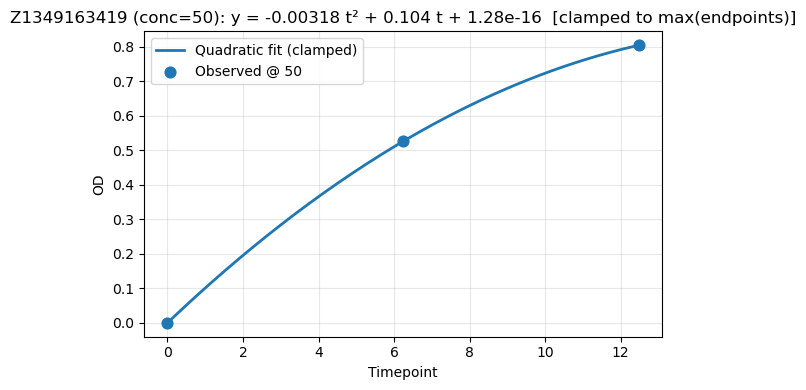

Quadratic coefficients [a, b, c]: [-3.18225489e-03  1.04231764e-01  1.28197512e-16]


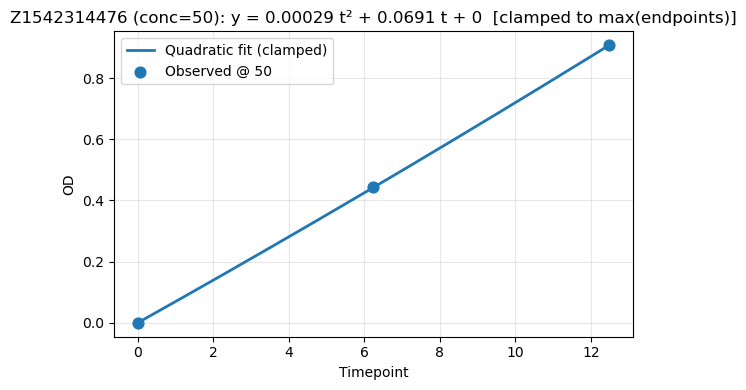

Quadratic coefficients [a, b, c]: [0.00028979 0.06908796 0.        ]


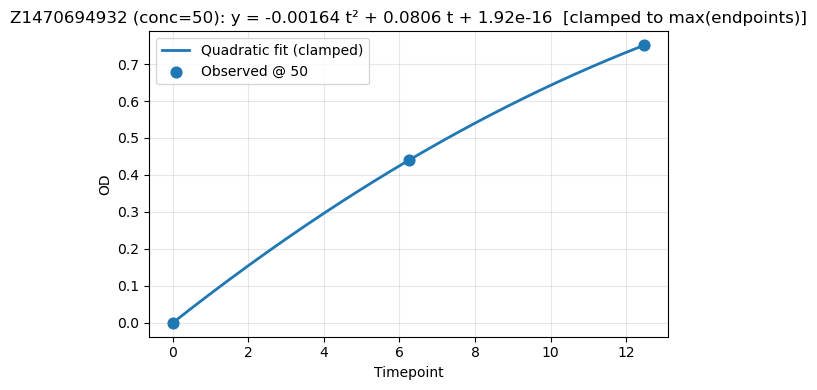

Quadratic coefficients [a, b, c]: [-1.63904184e-03  8.06292809e-02  1.92296269e-16]


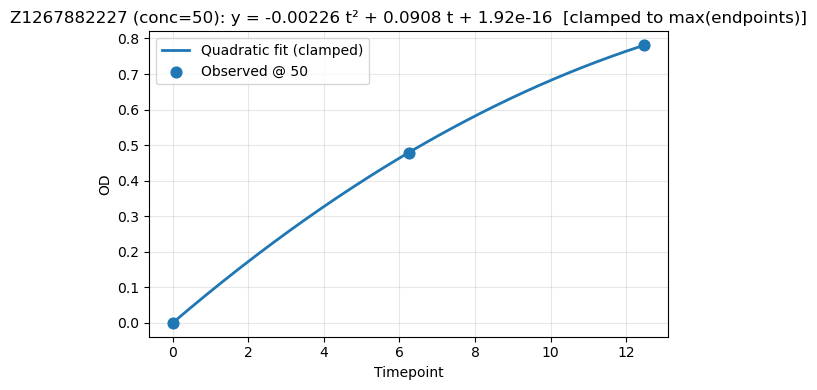

Quadratic coefficients [a, b, c]: [-2.26284259e-03  9.08198380e-02  1.92296269e-16]


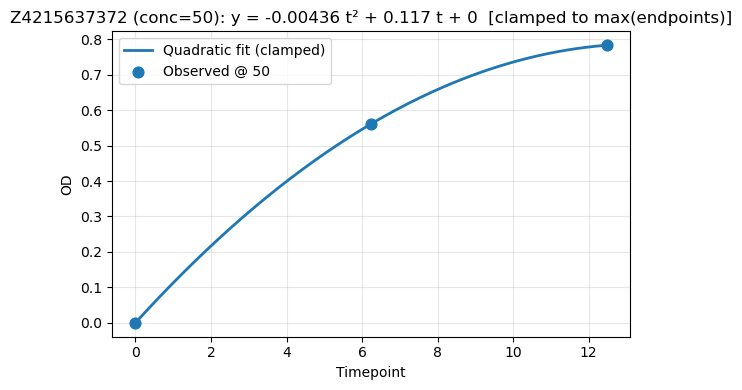

Quadratic coefficients [a, b, c]: [-0.00435756  0.1171174   0.        ]


In [16]:
for active in df_only_50[df_only_50['is_Active'] == 1]['Compound'].unique():


    coeffs, fig, ax = plot_single_conc_quadratic(df_train,active)
    print("Quadratic coefficients [a, b, c]:", coeffs)

## Inactives

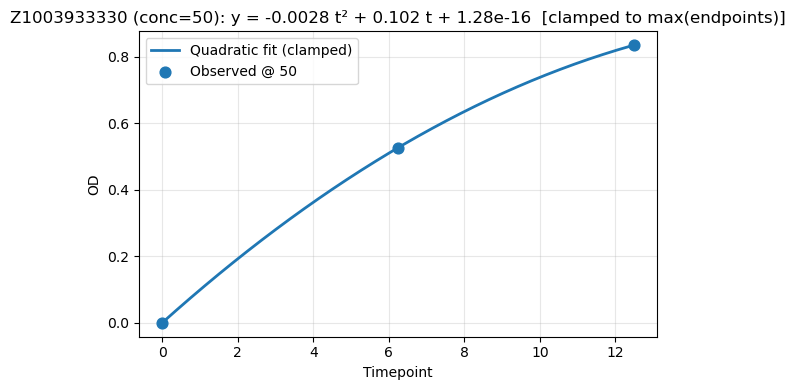

Quadratic coefficients [a, b, c]: [-2.79547228e-03  1.01774336e-01  1.28197512e-16]


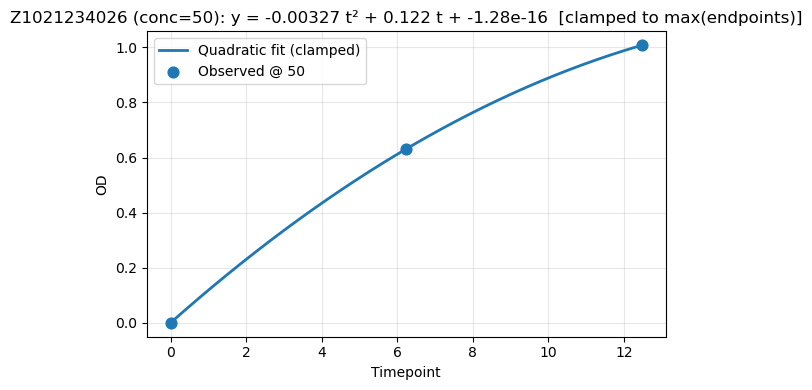

Quadratic coefficients [a, b, c]: [-3.27254028e-03  1.21569698e-01 -1.28197512e-16]


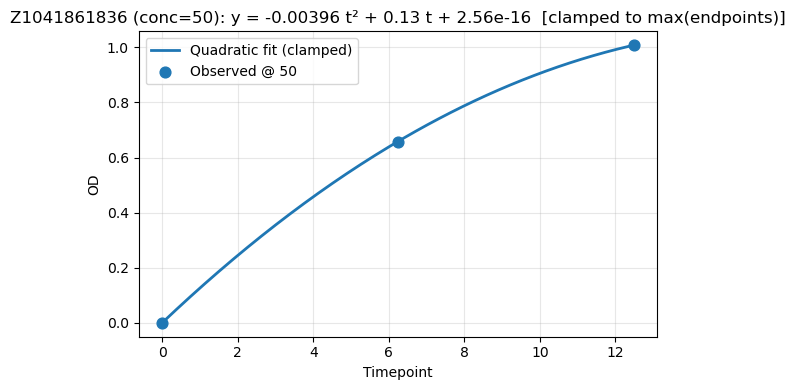

Quadratic coefficients [a, b, c]: [-3.96333700e-03  1.30213079e-01  2.56395025e-16]


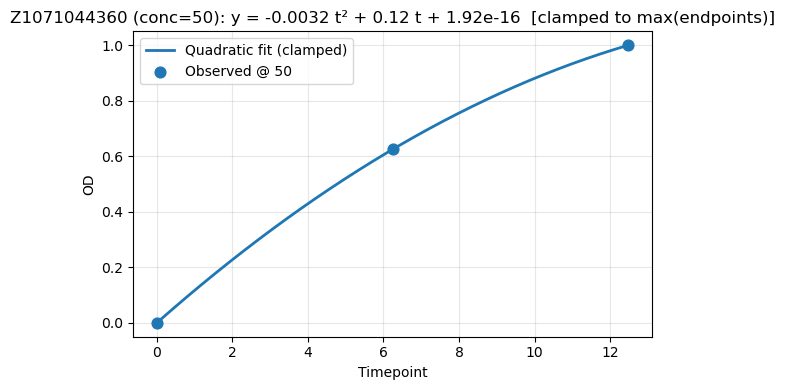

Quadratic coefficients [a, b, c]: [-3.20177910e-03  1.20059586e-01  1.92296269e-16]


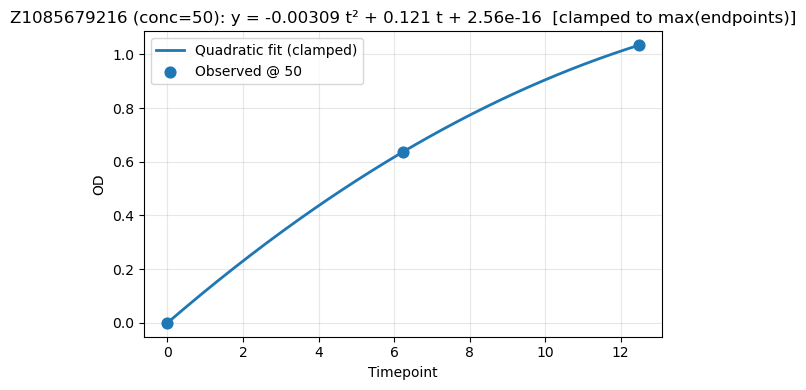

Quadratic coefficients [a, b, c]: [-3.08737467e-03  1.21377168e-01  2.56395025e-16]


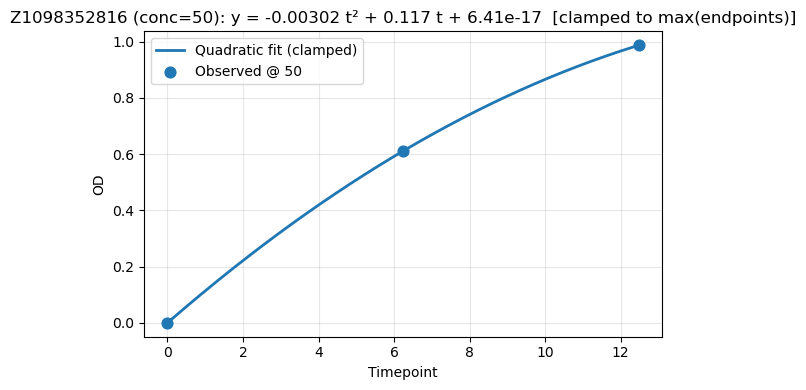

Quadratic coefficients [a, b, c]: [-3.01888360e-03  1.16780503e-01  6.40987562e-17]


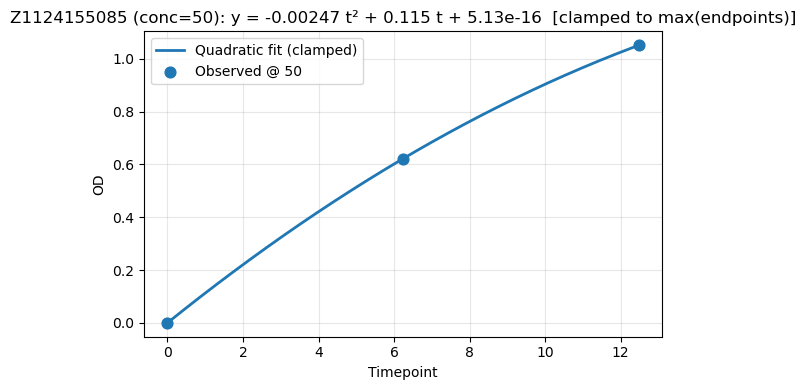

Quadratic coefficients [a, b, c]: [-2.47483416e-03  1.15129102e-01  5.12790050e-16]


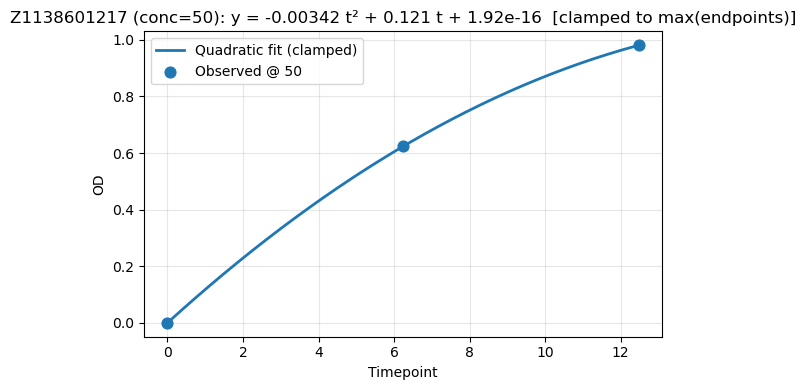

Quadratic coefficients [a, b, c]: [-3.42225227e-03  1.21331171e-01  1.92296269e-16]


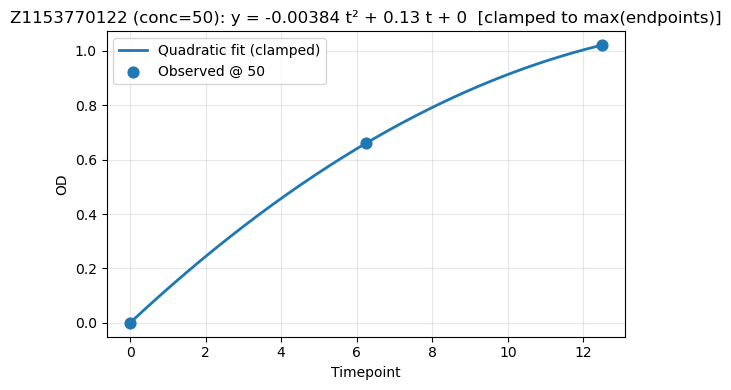

Quadratic coefficients [a, b, c]: [-0.00384097  0.12969932  0.        ]


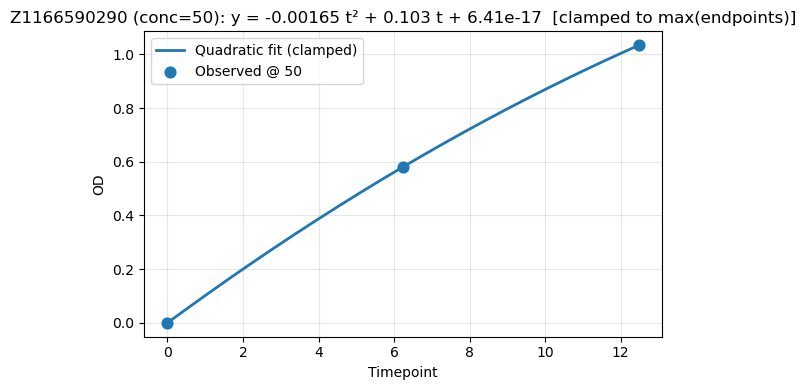

Quadratic coefficients [a, b, c]: [-1.64766467e-03  1.03441754e-01  6.40987562e-17]


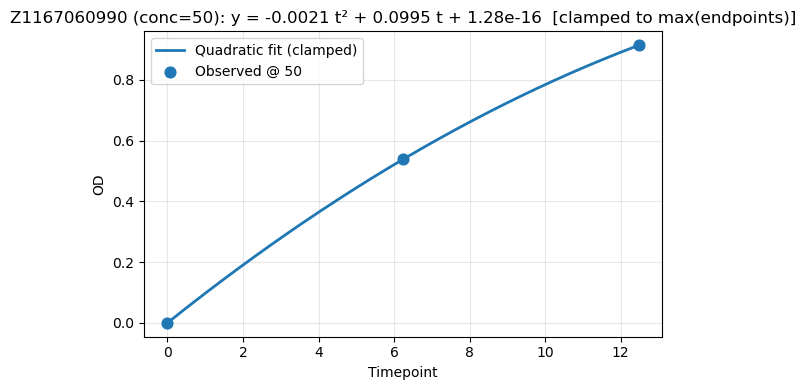

Quadratic coefficients [a, b, c]: [-2.09746915e-03  9.94595495e-02  1.28197512e-16]


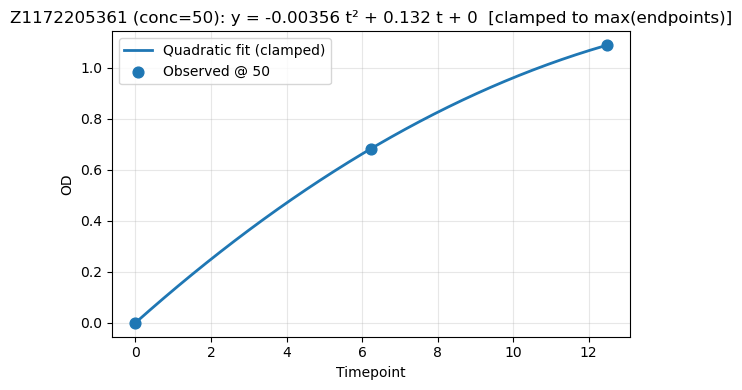

Quadratic coefficients [a, b, c]: [-0.00356436  0.13161376  0.        ]


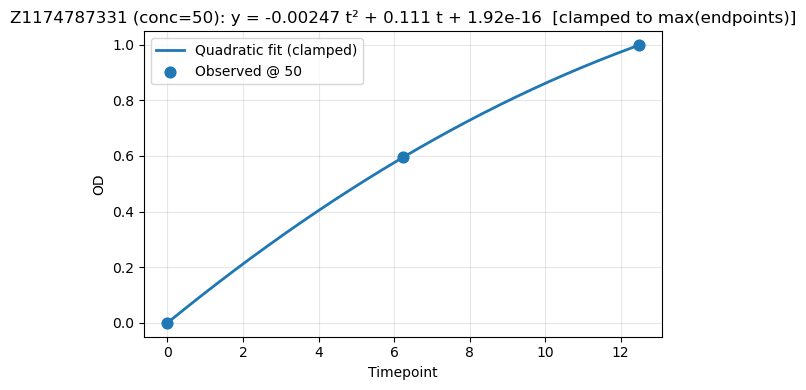

Quadratic coefficients [a, b, c]: [-2.47210508e-03  1.10804841e-01  1.92296269e-16]


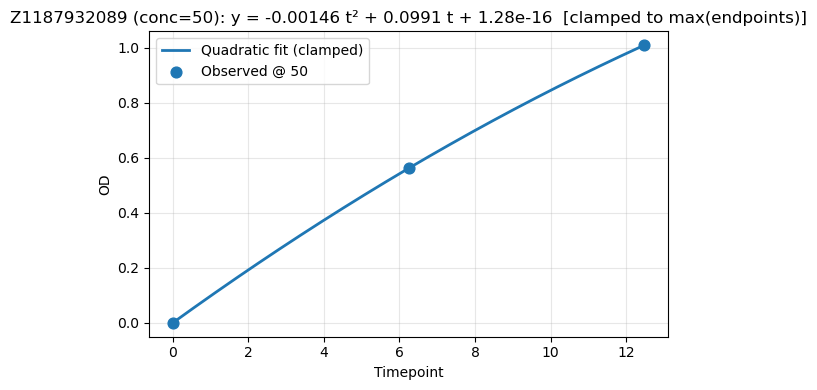

Quadratic coefficients [a, b, c]: [-1.46139774e-03  9.91200507e-02  1.28197512e-16]


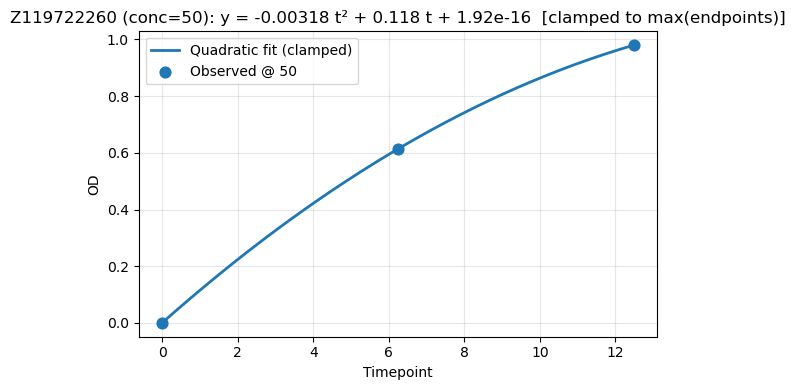

Quadratic coefficients [a, b, c]: [-3.17550850e-03  1.18139713e-01  1.92296269e-16]


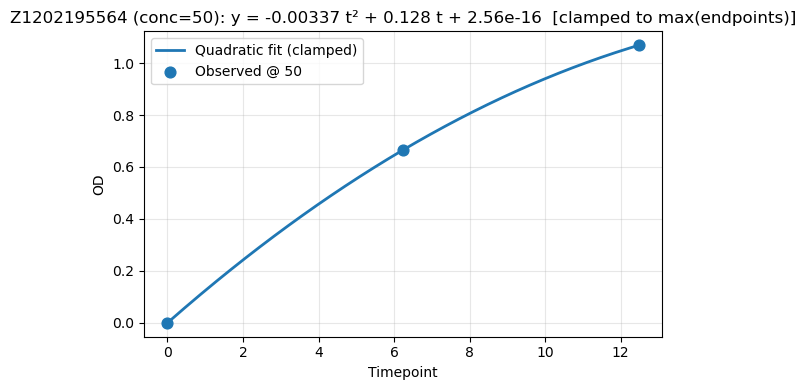

Quadratic coefficients [a, b, c]: [-3.37497487e-03  1.27745887e-01  2.56395025e-16]


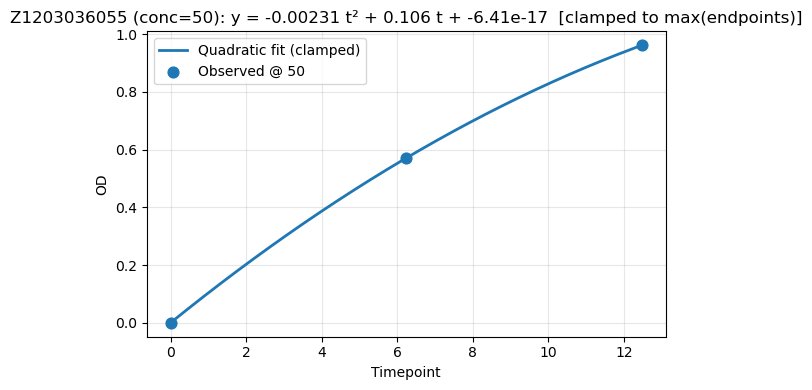

Quadratic coefficients [a, b, c]: [-2.31300948e-03  1.05909356e-01 -6.40987562e-17]


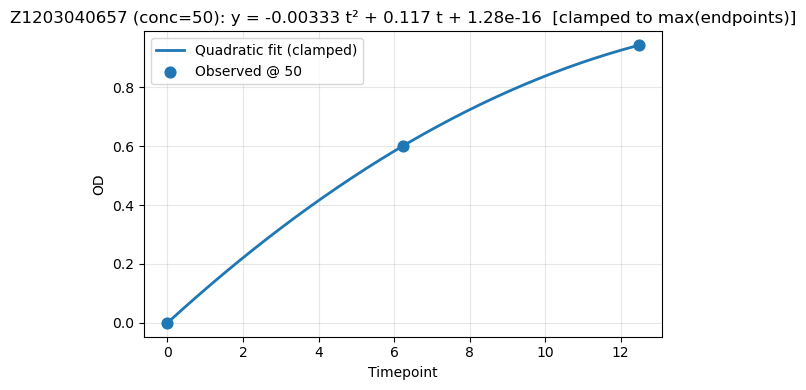

Quadratic coefficients [a, b, c]: [-3.33436052e-03  1.17139693e-01  1.28197512e-16]


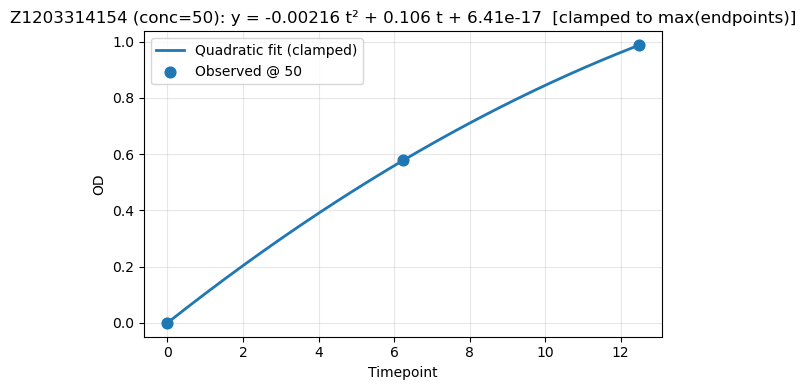

Quadratic coefficients [a, b, c]: [-2.15990588e-03  1.06028715e-01  6.40987562e-17]


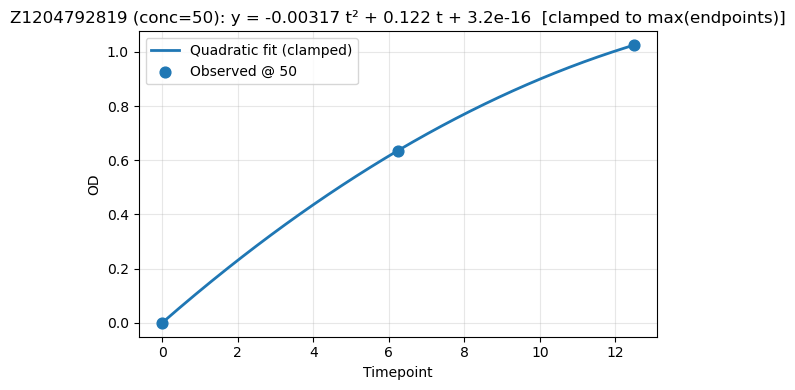

Quadratic coefficients [a, b, c]: [-3.16849983e-03  1.21662746e-01  3.20493781e-16]


In [17]:
i=0
for inactive in df_only_50[df_only_50['is_Active'] == 0]['Compound'].unique():
    if i ==20:
        break

    coeffs, fig, ax = plot_single_conc_quadratic(df_train,inactive)
    print("Quadratic coefficients [a, b, c]:", coeffs)
    i=i+1